In [1]:
import os
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import xgboost as xgb
import lightgbm as lgb

In [2]:
import sys
sys.path.append("../..")

from regression import simple_regression, cross_gen, interaction_regression, huber_regression, decision_tree, random_forest, extra_trees, xgboost_model, lightgbm_model, gpr_matern, gpr_rational_quadratic, ann, predict_gpr_in_batches, predict_ann_in_batches

In [3]:
DATA_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/Feature_extraction/Non_fiducial_features/8sec_0overlap/data"

train_path = os.path.join(DATA_DIR, "DBP_FTEST_train.csv")
val_path   = os.path.join(DATA_DIR, "DBP_FTEST_val.csv")
test_path  = os.path.join(DATA_DIR, "DBP_FTEST_test.csv")

df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)
df_test  = pd.read_csv(test_path)

print("Train:", df_train.shape)
print("Val:  ", df_val.shape)
print("Test: ", df_test.shape)

Train: (263103, 16)
Val:   (33223, 16)
Test:  (33347, 16)


In [4]:
TARGET = "DBP"

X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]

X_val = df_val.drop(columns=[TARGET])
y_val = df_val[TARGET]

X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

X_train: (263103, 15)
y_train: (263103,)
X_val:   (33223, 15)
y_val:   (33223,)
X_test:  (33347, 15)
y_test:  (33347,)


In [5]:
VITAL_PATH = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/8sec_0overlap/data/DBP_FTEST_vitaldb.csv"
vital_test = pd.read_csv(VITAL_PATH)
print(vital_test.shape)
print(df_train.head())

(2928374, 17)
   apg_kte_iqr  apg_kte_mean  vpg_median   apg_iqr  ppg_mean   apg_std  \
0    -0.548634     -0.499628   -2.880214 -0.407478  3.272922 -0.778135   
1    -0.495748     -0.526044   -3.115539 -0.242859  2.855088 -0.741451   
2    -0.620325     -0.647697   -2.930166 -0.538027  3.195013 -0.987031   
3    -0.503614     -0.530002   -2.791438 -0.253825  3.061656 -0.768058   
4    -0.519571     -0.540054   -2.948292 -0.297985  3.338505 -0.801642   

   vpg_kte_mean  apg_variance  apg_energy_mean  ppg_median  apg_median  \
0     -0.693926     -0.734180        -0.733928    3.323705   -1.598747   
1     -0.665856     -0.709743        -0.709529    2.850212   -1.197357   
2     -0.830737     -0.866318        -0.866282    3.174134   -1.534092   
3     -0.694000     -0.727504        -0.727482    3.100908   -1.384103   
4     -0.718387     -0.749646        -0.749327    3.343549   -1.327176   

   ppg_skewness  ppg_shannon_entropy  ppg_energy_skewness  vpg_kte_iqr  \
0     -2.870461       

In [6]:
X_test_vital = vital_test.drop(columns=[TARGET, "case_id"])
y_test_vital = vital_test[TARGET]

In [7]:
X_dev = pd.concat([X_train, X_val], axis=0)
y_dev = pd.concat([y_train, y_val], axis=0)

In [8]:
print("DBP min:", y_train.min())
print("DBP max:", y_train.max())
print("DBP mean:", y_train.mean())
print("DBP std:", y_train.std())

print("DBP > 80:", np.sum(y_train > 80))
print("DBP > 90:", np.sum(y_train > 90))
print("DBP > 100:", np.sum(y_train > 100))

DBP min: 50.0
DBP max: 149.80486780343182
DBP mean: 66.41287378707464
DBP std: 10.878506659869677
DBP > 80: 29106
DBP > 90: 8829
DBP > 100: 2904


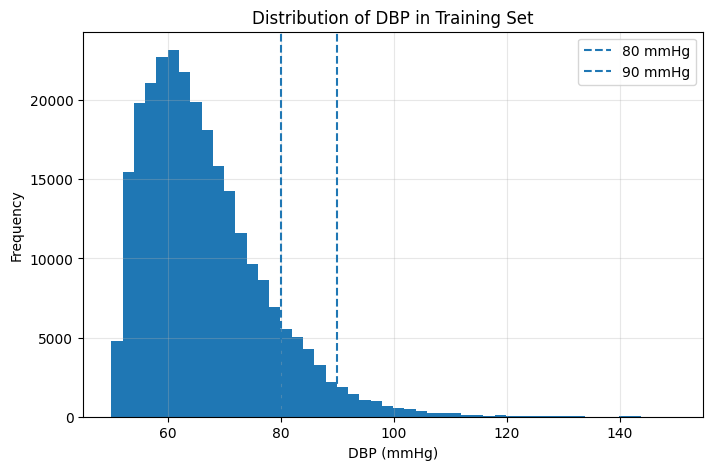

In [9]:
from matplotlib import pyplot as plt
plt.figure(figsize=(8,5))

plt.hist(y_train, bins=50)

plt.axvline(80, linestyle="--", label="80 mmHg")
plt.axvline(90, linestyle="--", label="90 mmHg")

plt.xlabel("DBP (mmHg)")
plt.ylabel("Frequency")
plt.title("Distribution of DBP in Training Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## SIMPLE LINEAR REGRESSION ##

Simple Linear Regression
------------------------
Target: DBP
RMSE: 10.4055
MSE : 108.2753
R²  : 0.1333
MAE : 8.0989


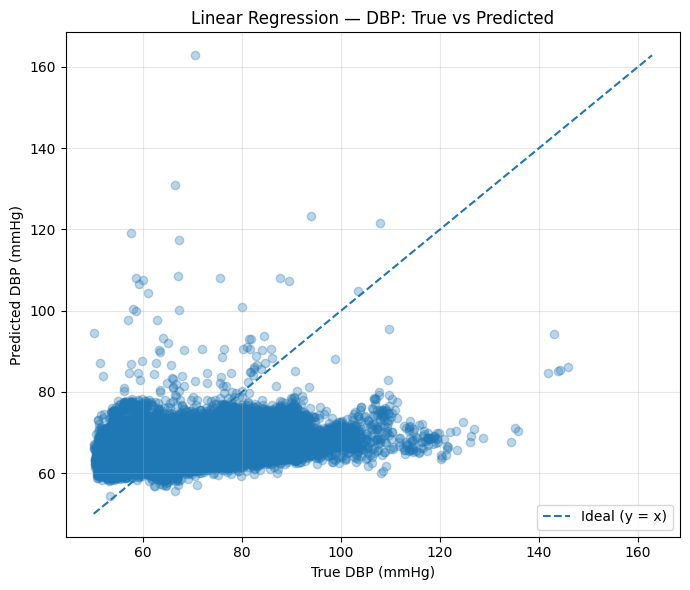

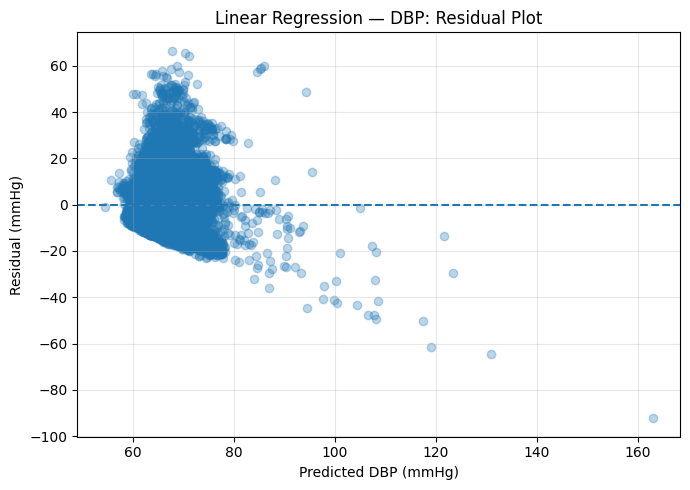

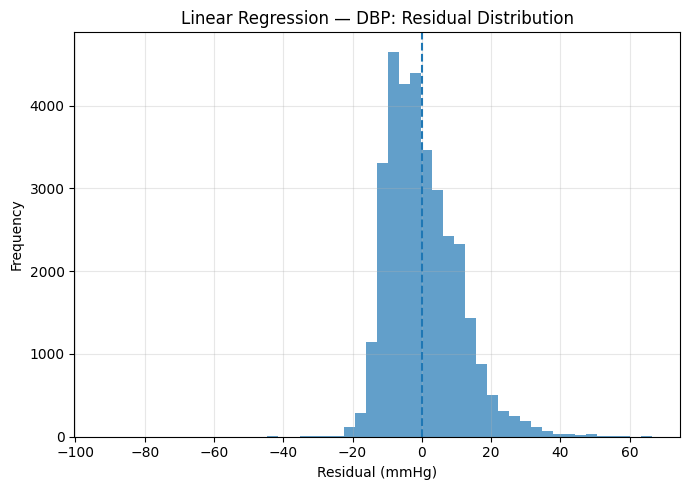

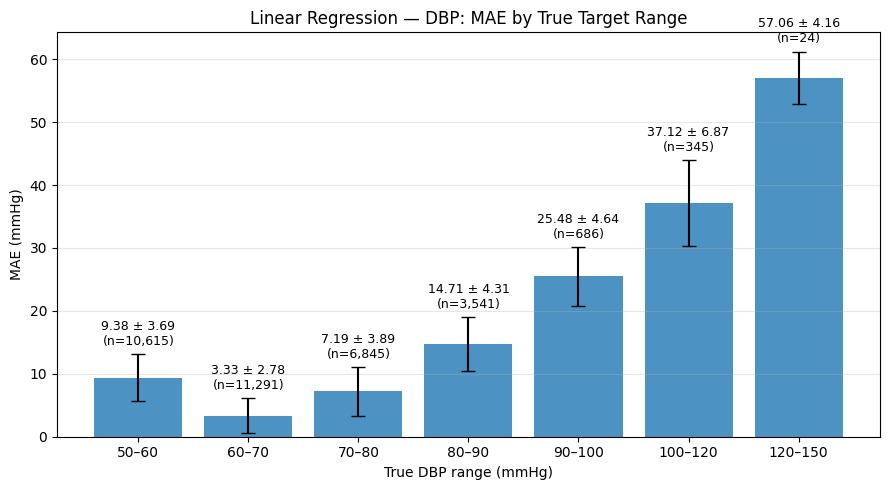

In [10]:
linear_model, y_test_pred = simple_regression(X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 19.2203
MSE : 369.4197
R²  : -1.2823
MAE : 14.3186


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


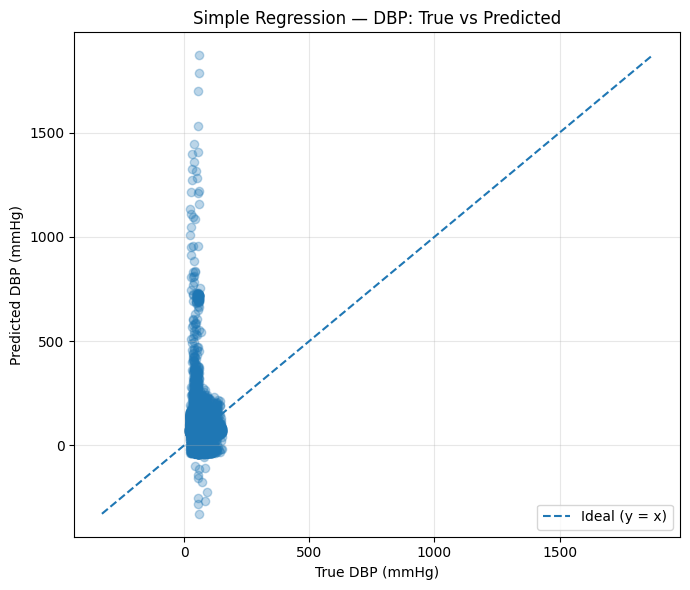

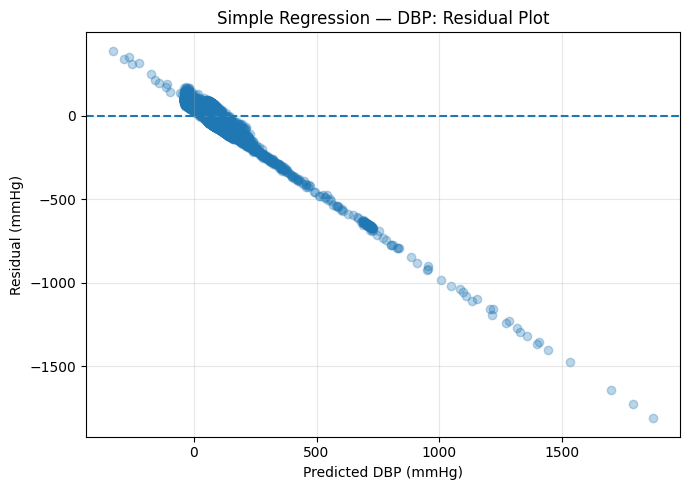

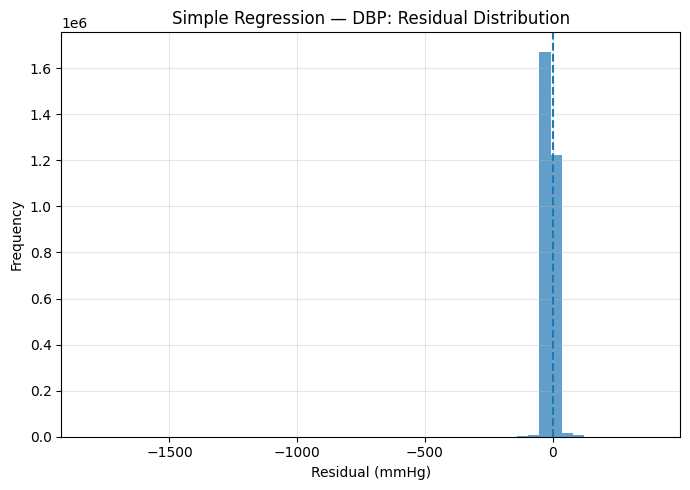

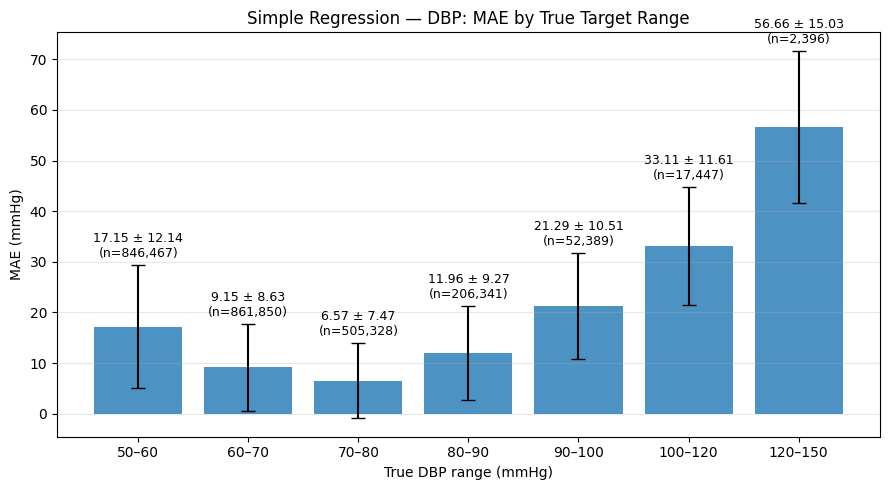

In [11]:
cross_gen(
    X_test_vital,
    y_test_vital,
    linear_model,
    "Simple Regression",
    TARGET
)

## INTERACTION LINEAR REGRESSION ##

Best parameters:
{'linear__fit_intercept': True}

Interaction Linear Regression — DBP
---------------------------------------------
RMSE: 9.9518
MSE : 99.0393
R²  : 0.2072
MAE : 7.6884


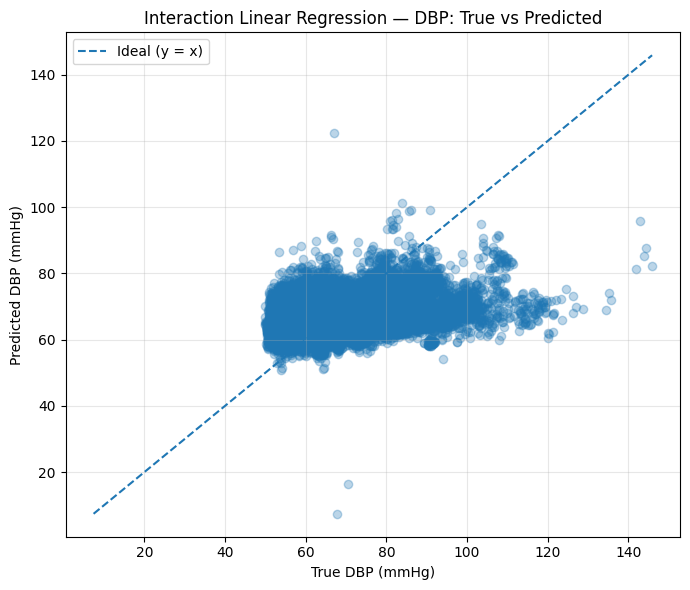

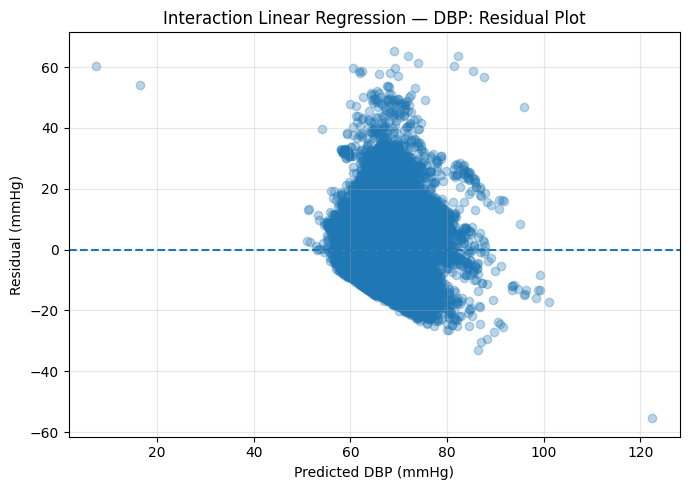

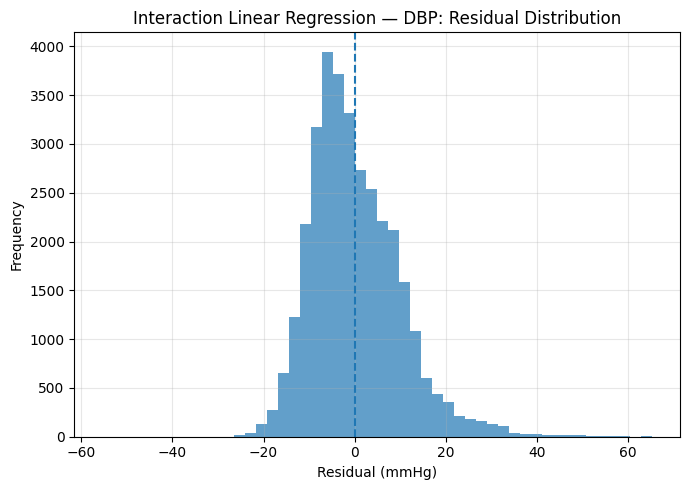

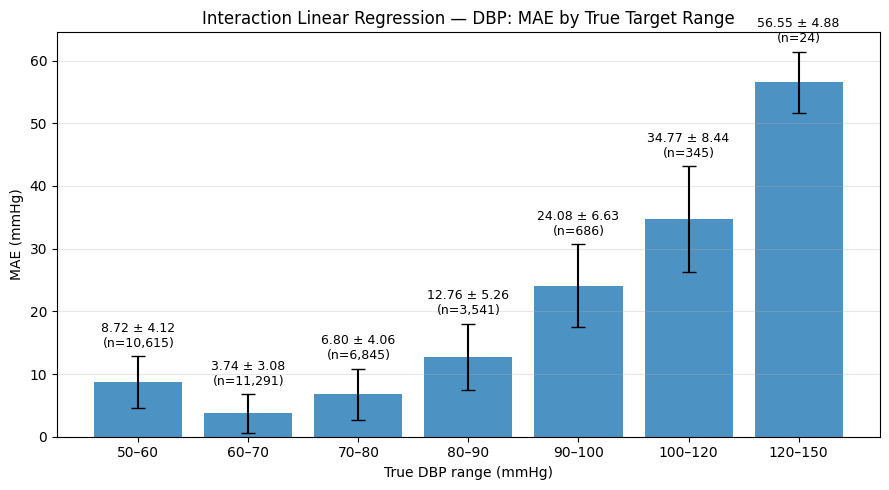

In [12]:
grid_interaction, y_test_pred = interaction_regression(X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 172.9158
MSE : 29899.8604
R²  : -183.7231
MAE : 23.5051


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


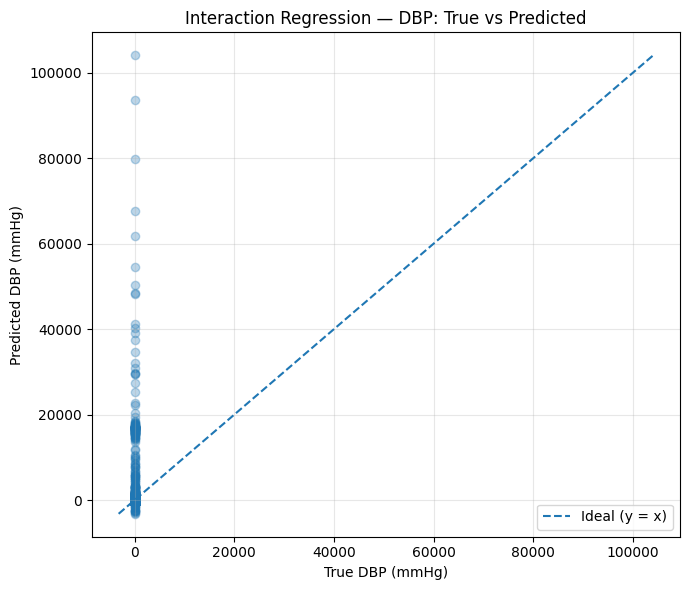

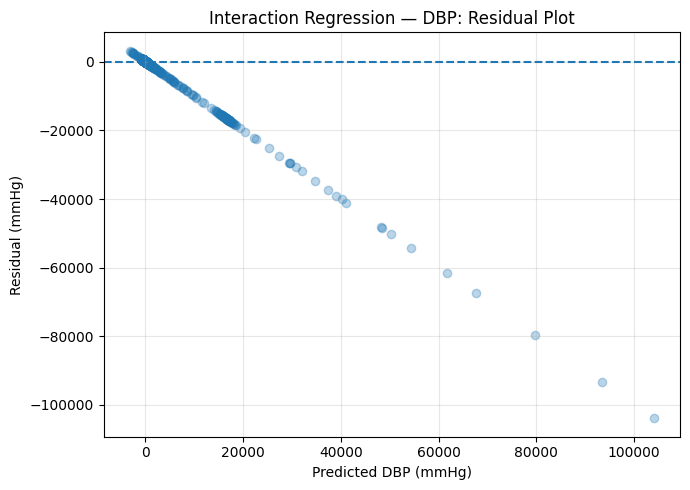

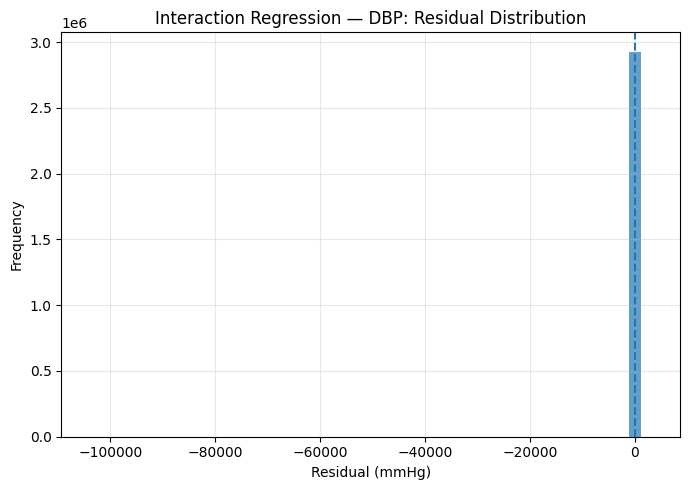

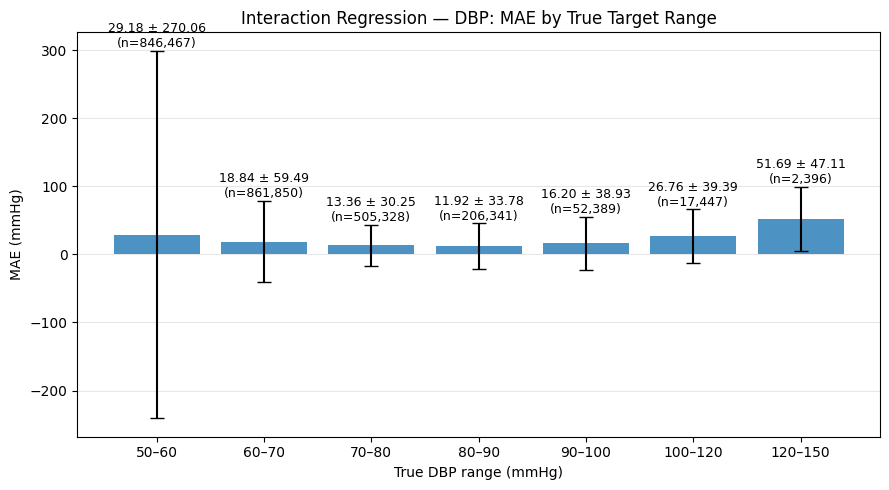

In [13]:
cross_gen(
    X_test_vital,
    y_test_vital,
    grid_interaction,
    "Interaction Regression",
    TARGET
)

## Robust Linear Regression ##

Best parameters:
{'alpha': 1.0, 'epsilon': 2.0}

Robust Linear Regression — DBP
----------------------------------------
RMSE: 10.4801
MSE : 109.8315
R²  : 0.1208
MAE : 8.0106


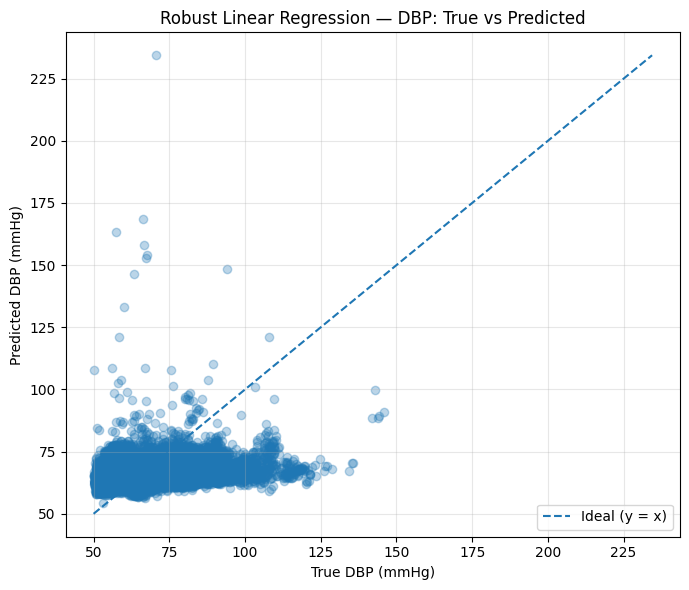

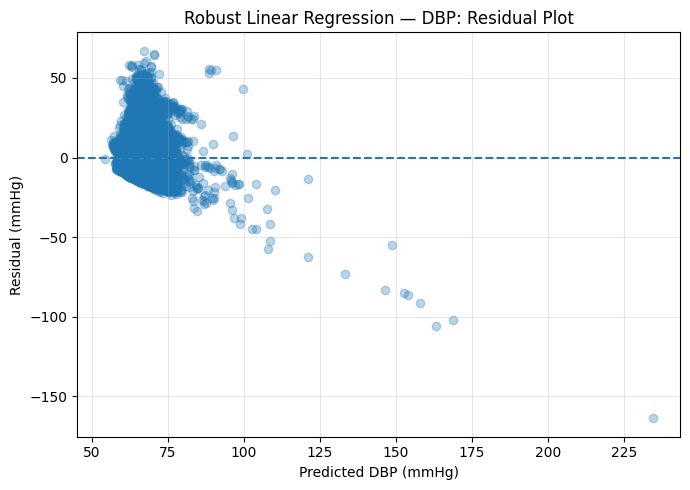

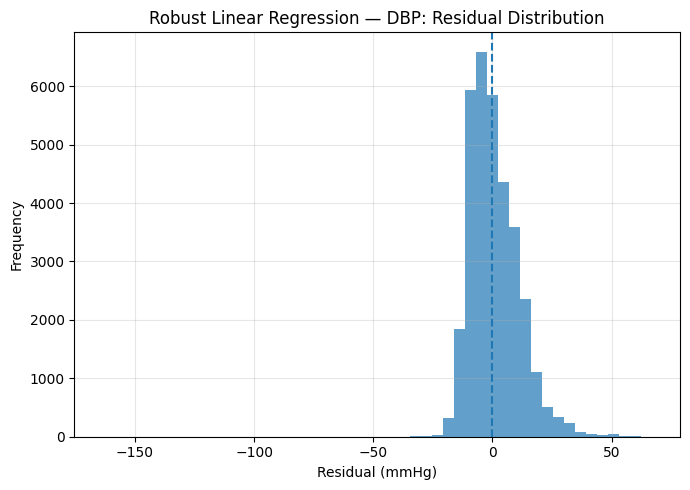

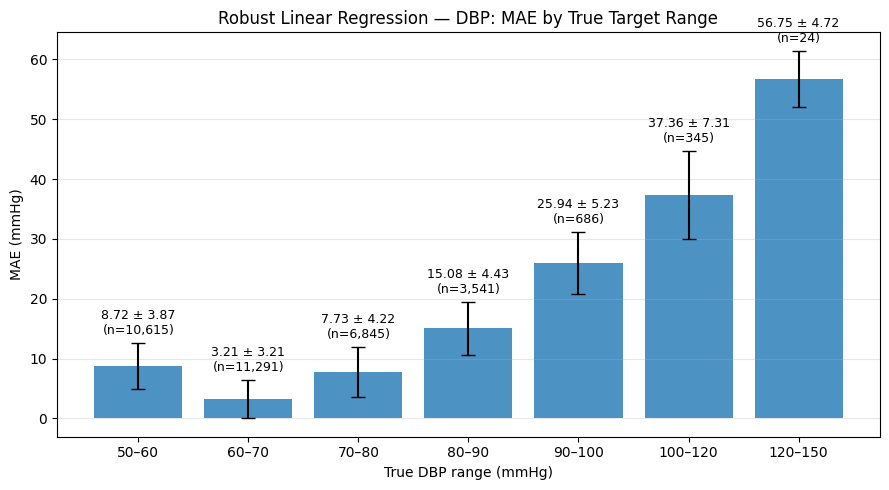

In [14]:
huber_model, y_test_pred = huber_regression(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 21.9481
MSE : 481.7212
R²  : -1.9761
MAE : 15.9165


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


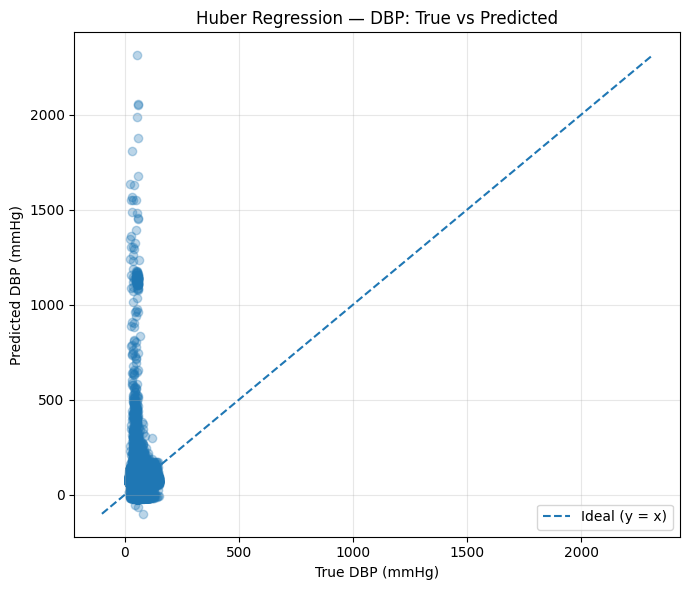

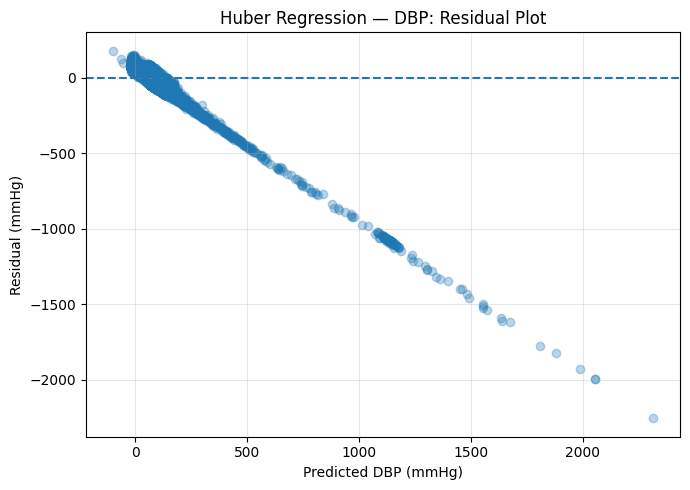

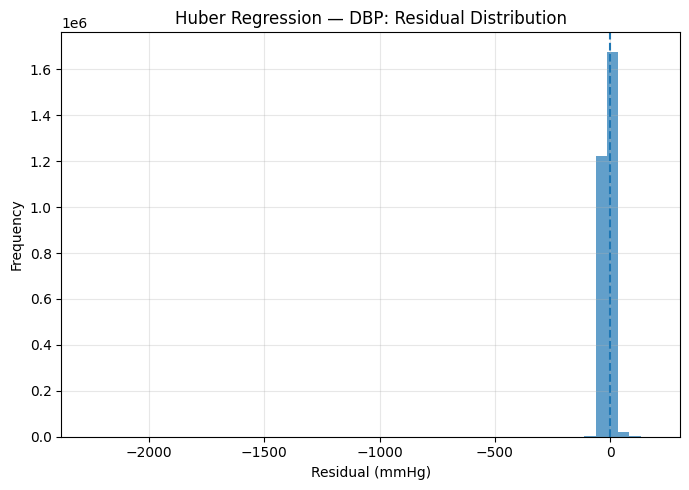

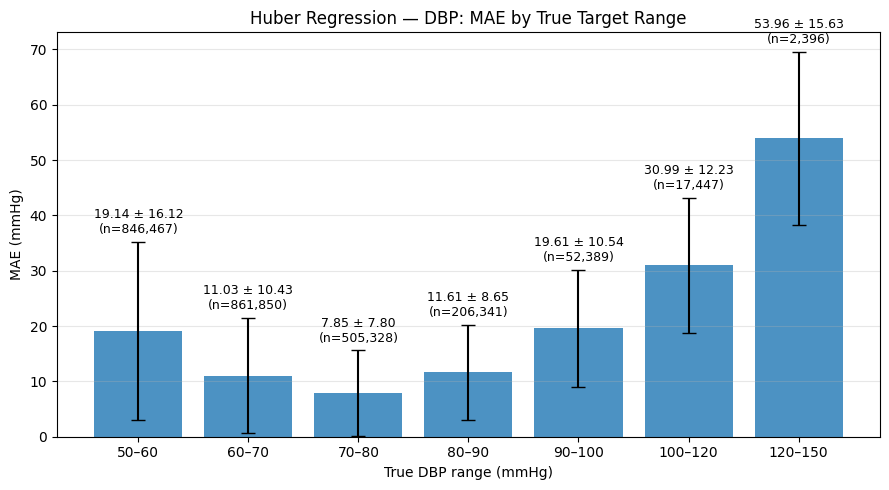

In [15]:
cross_gen(
    X_test_vital,
    y_test_vital,
    huber_model,
    "Huber Regression",
    TARGET
)

## Fine Decision Tree ##

Best parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}

Fine Decision Tree — DBP
--------------------------------
RMSE: 10.1348
MSE : 102.7151
R²  : 0.1778
MAE : 7.6555


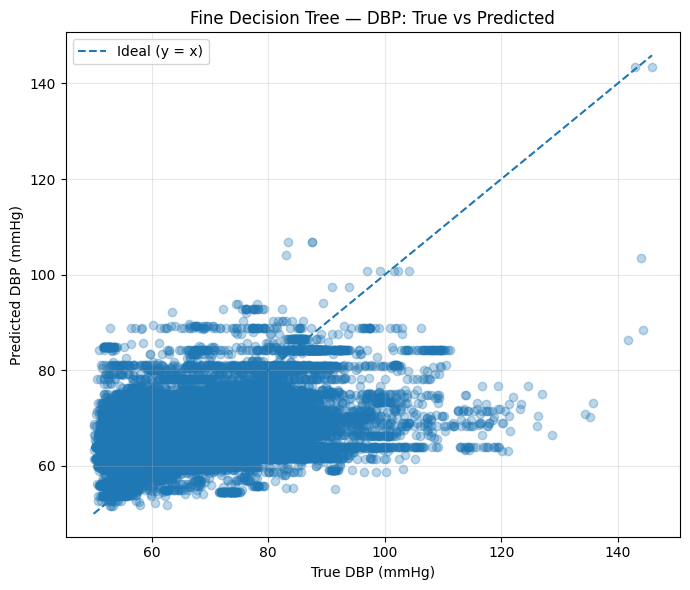

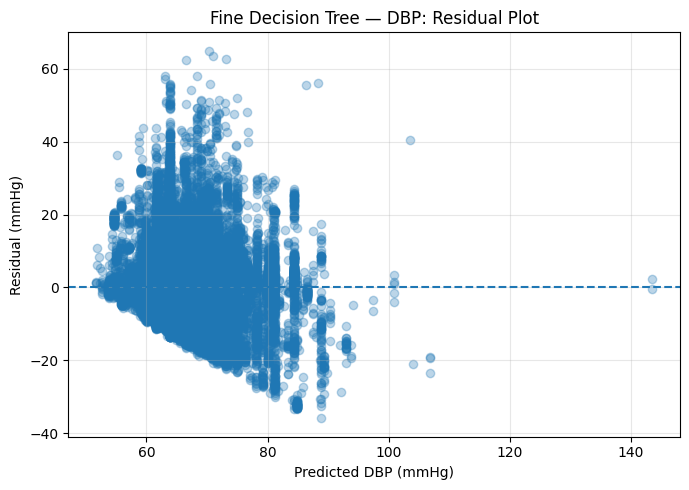

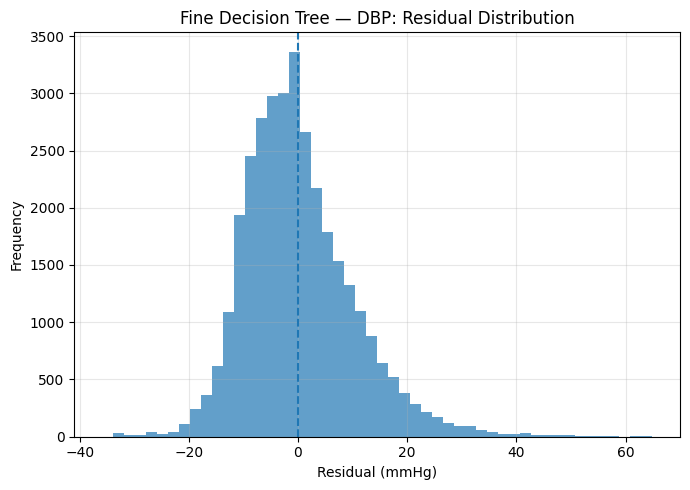

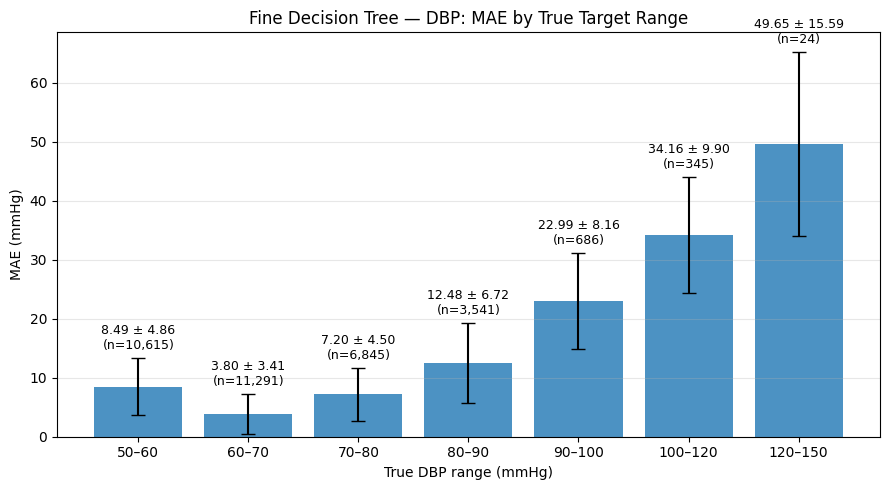

In [16]:
tree_model, y_test_pred = decision_tree(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)


RMSE: 13.2258
MSE : 174.9224
R²  : -0.0807
MAE : 10.3162


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


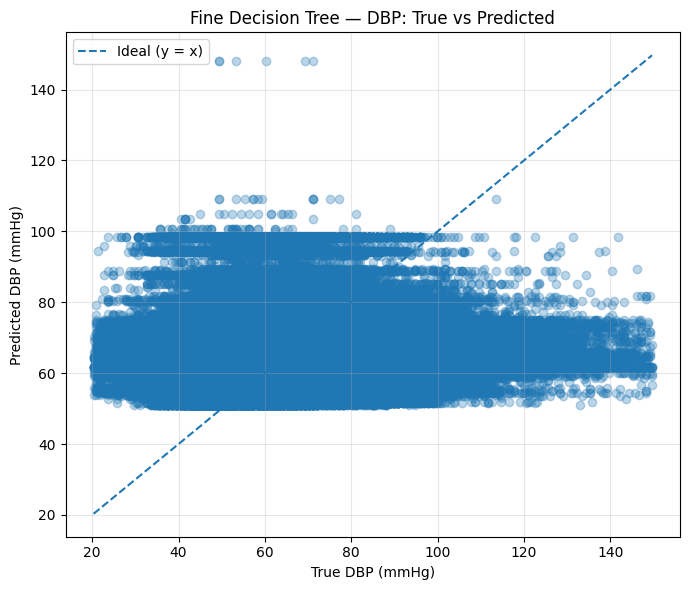

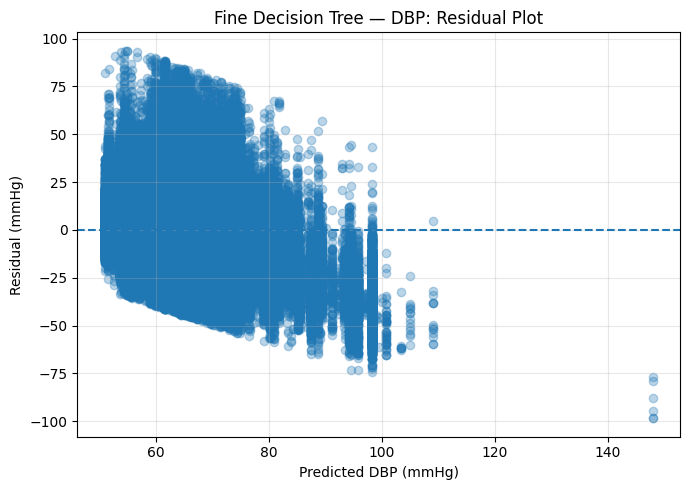

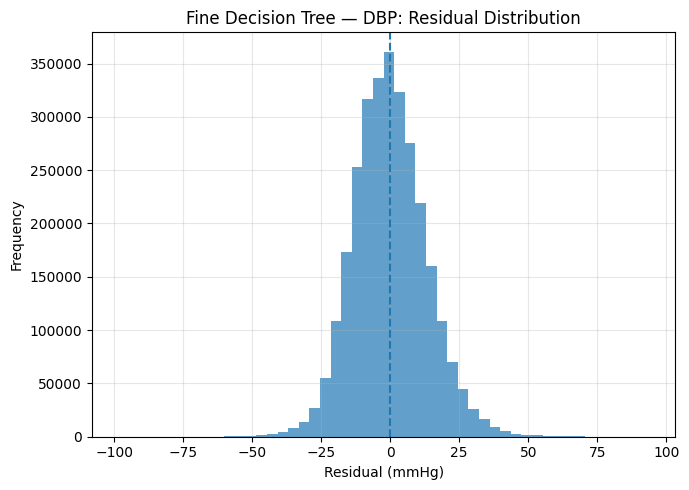

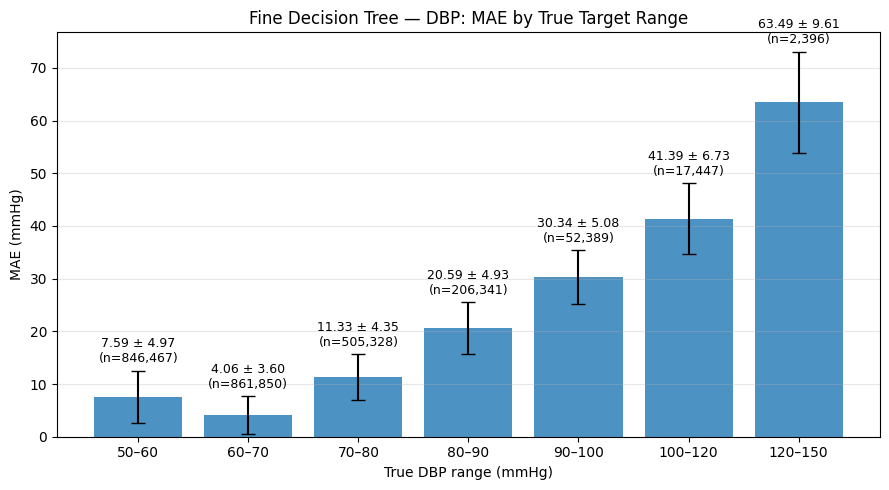

In [17]:
cross_gen(
    X_test_vital,
    y_test_vital,
    tree_model,
    "Fine Decision Tree",
    TARGET
)

## Random Forest ##

/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Random Forest — DBP
----------------------------
RMSE: 8.8960
MSE : 79.1395
R²  : 0.3665
MAE : 6.4767


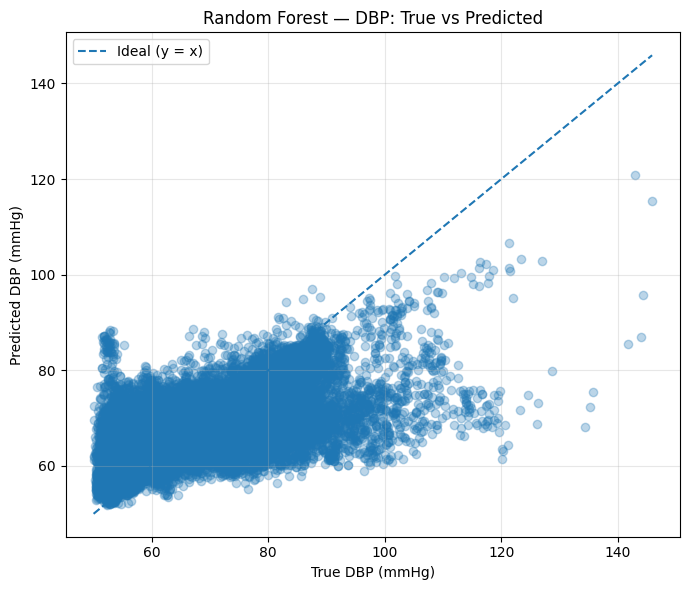

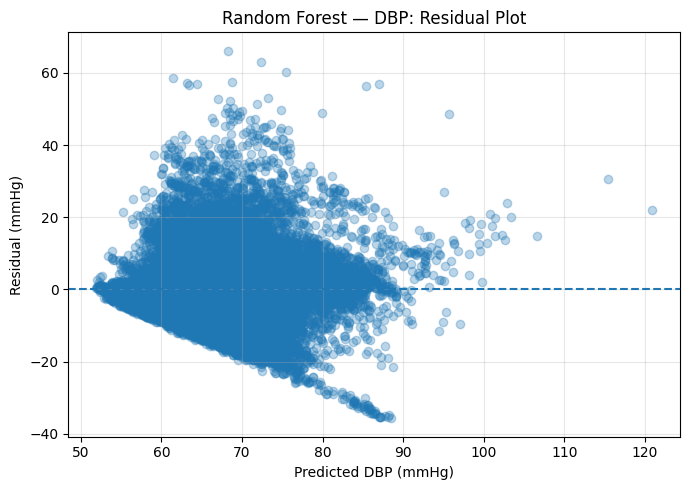

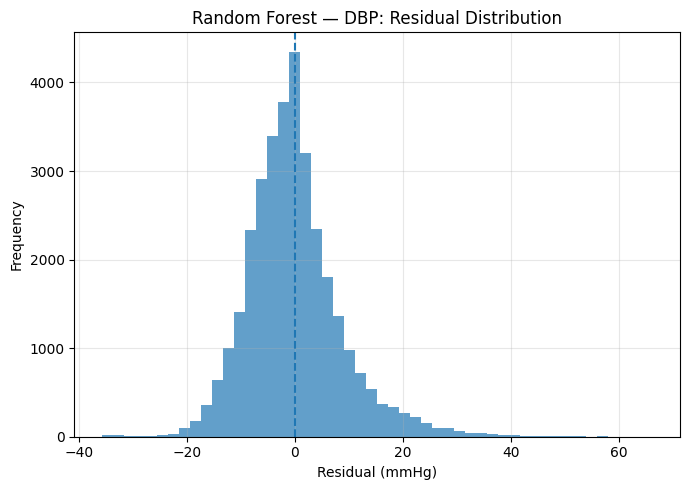

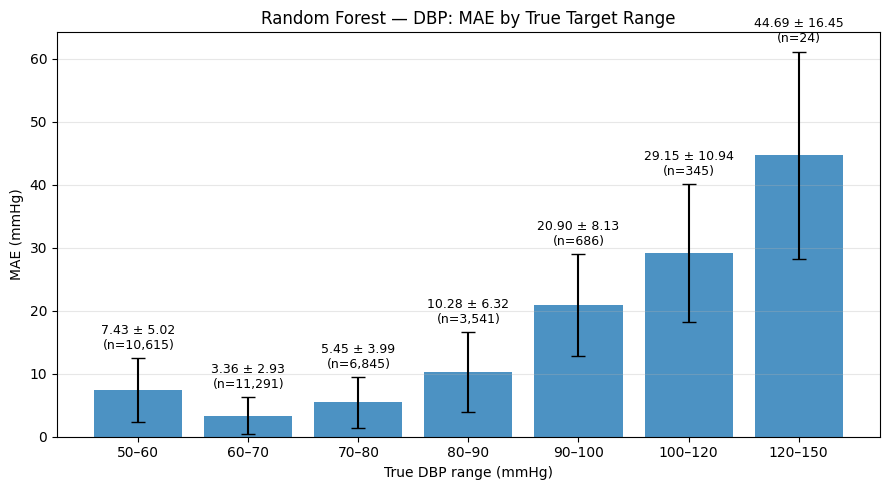

In [18]:
rf_model, y_test_pred = random_forest(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 13.1895
MSE : 173.9630
R²  : -0.0748
MAE : 10.5502


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


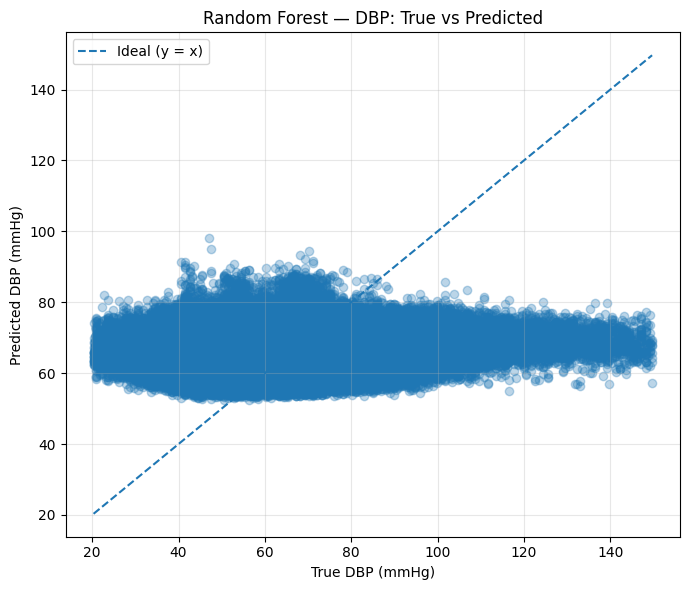

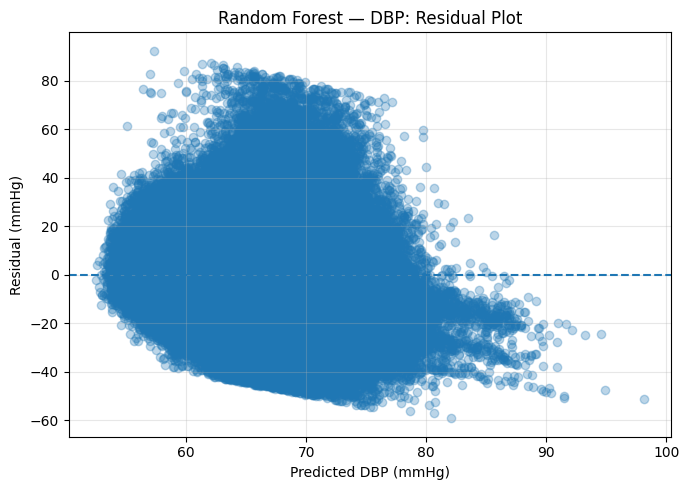

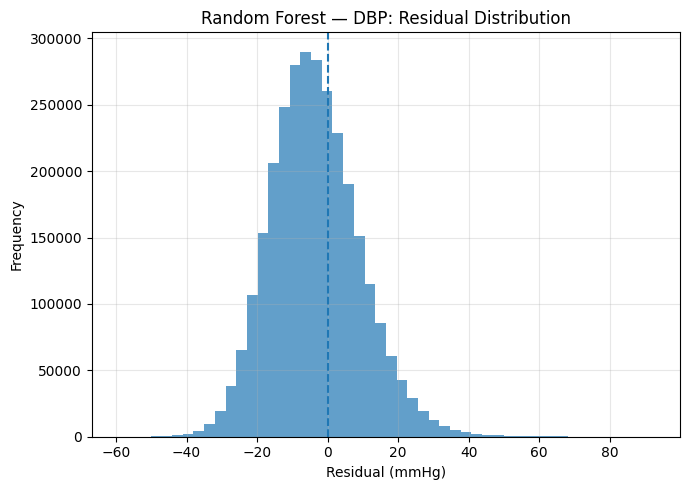

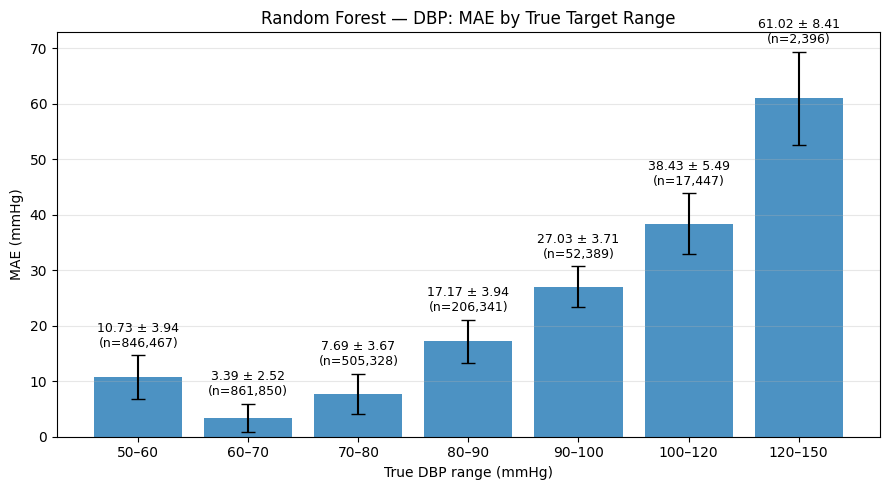

In [19]:
cross_gen(
    X_test_vital,
    y_test_vital,
    rf_model,
    "Random Forest",
    TARGET
)

## Extra TREES ##

/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'max_depth': 30, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Extra Trees Regressor — DBP
--------------------------------------
RMSE: 8.7850
MSE : 77.1758
R²  : 0.3822
MAE : 6.3363


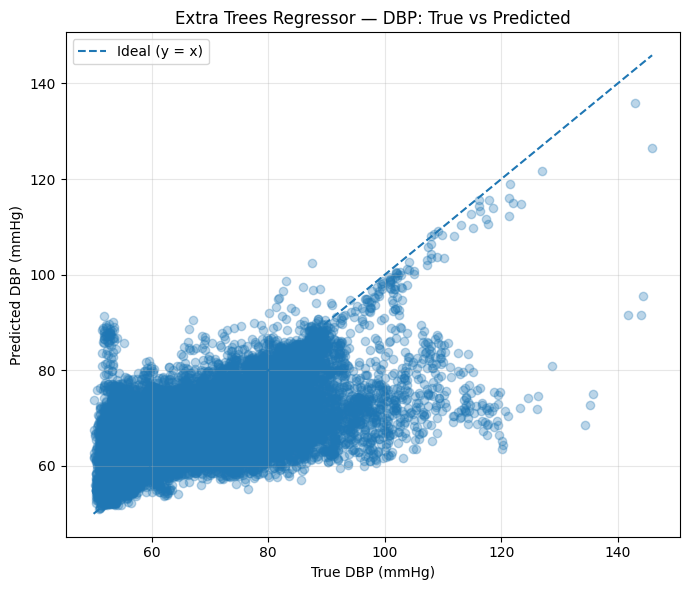

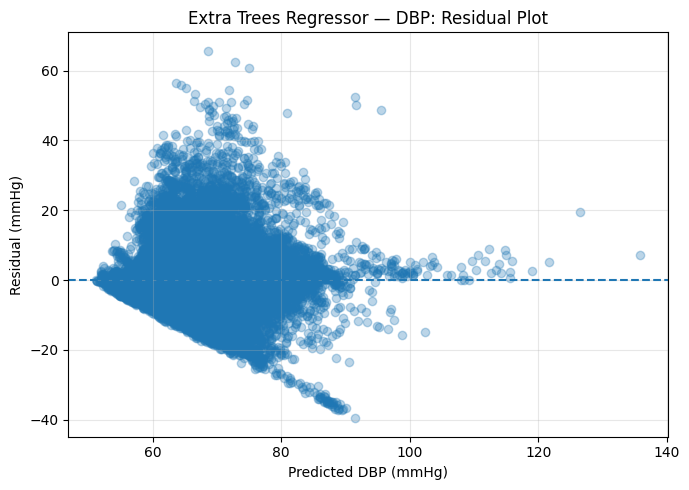

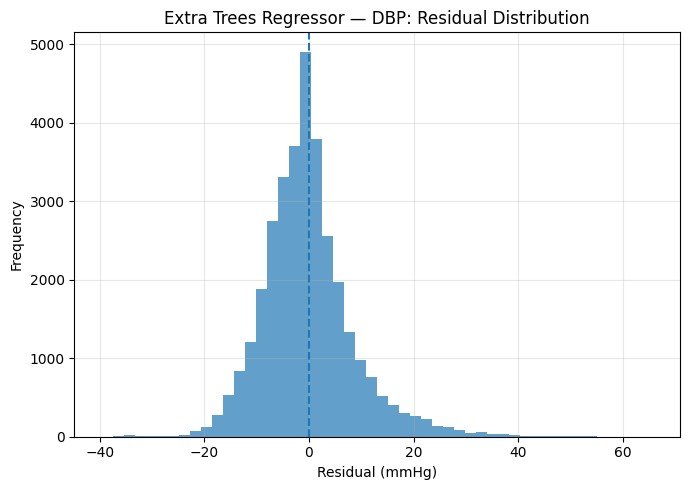

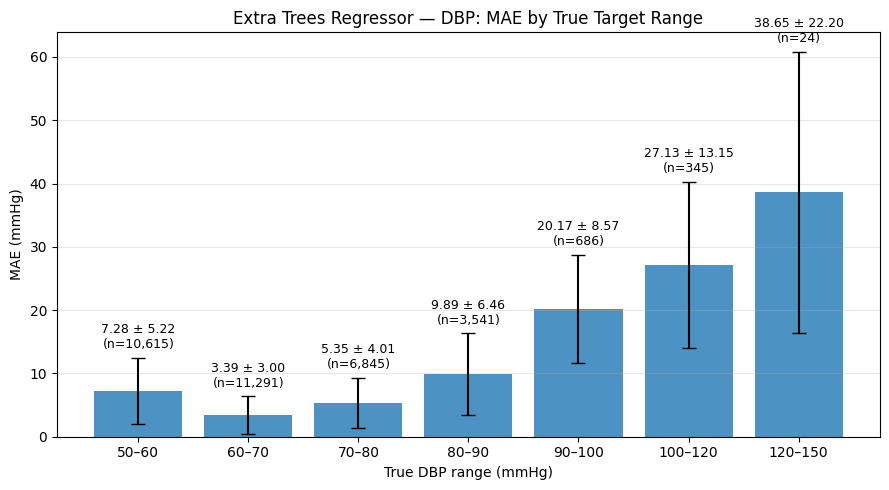

In [20]:
extra_trees_model, y_test_pred = extra_trees(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 13.2951
MSE : 176.7591
R²  : -0.0920
MAE : 10.6301


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


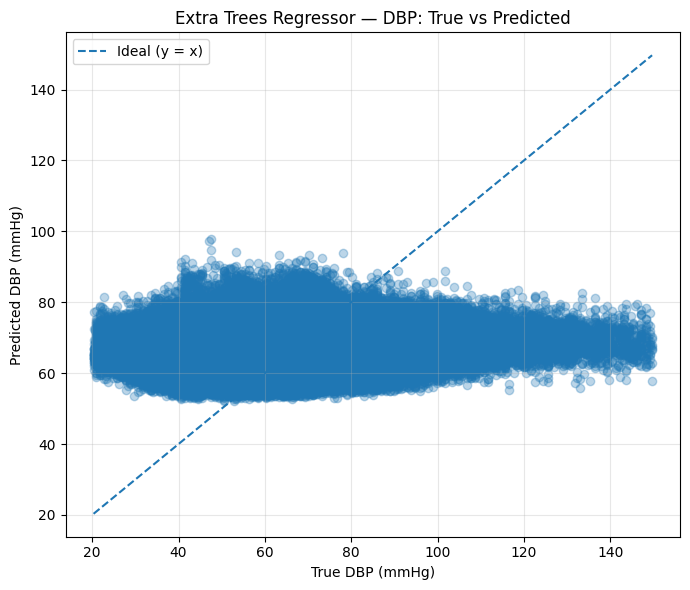

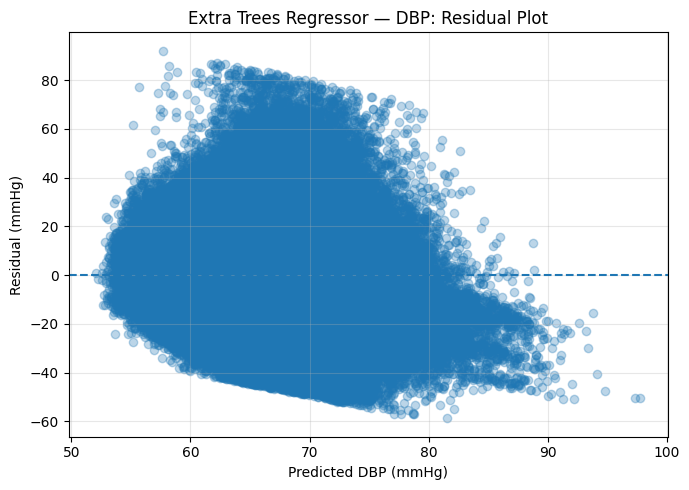

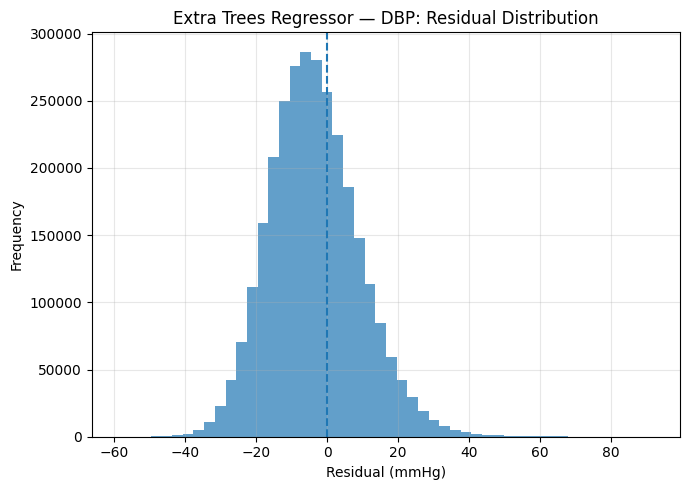

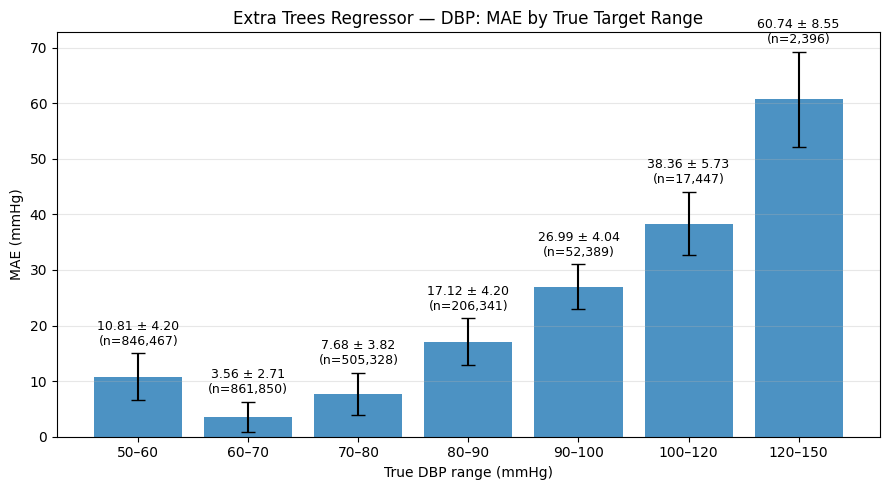

In [21]:
cross_gen(
    X_test_vital,
    y_test_vital,
    extra_trees_model,
    "Extra Trees Regressor",
    TARGET
)

## XGBOOST ##

Best parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}

XGBoost — DBP
---------------------
RMSE: 9.4042
MSE : 88.4395
R²  : 0.2920
MAE : 7.0055


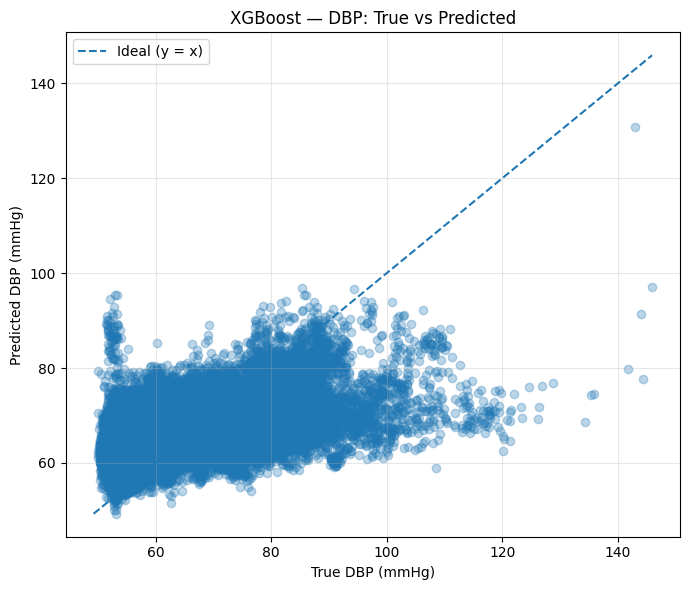

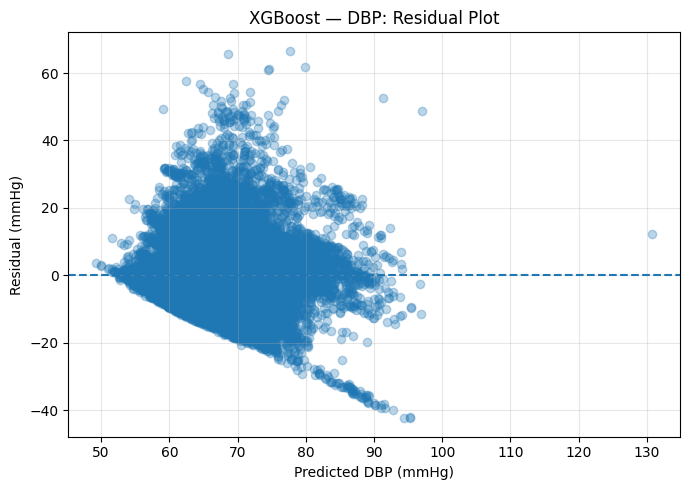

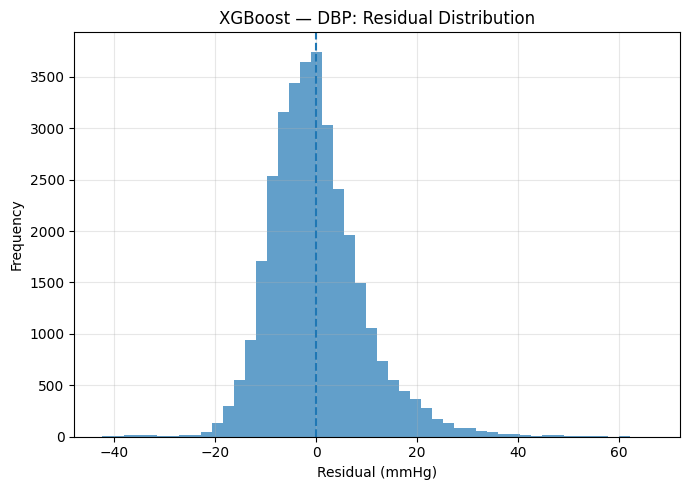

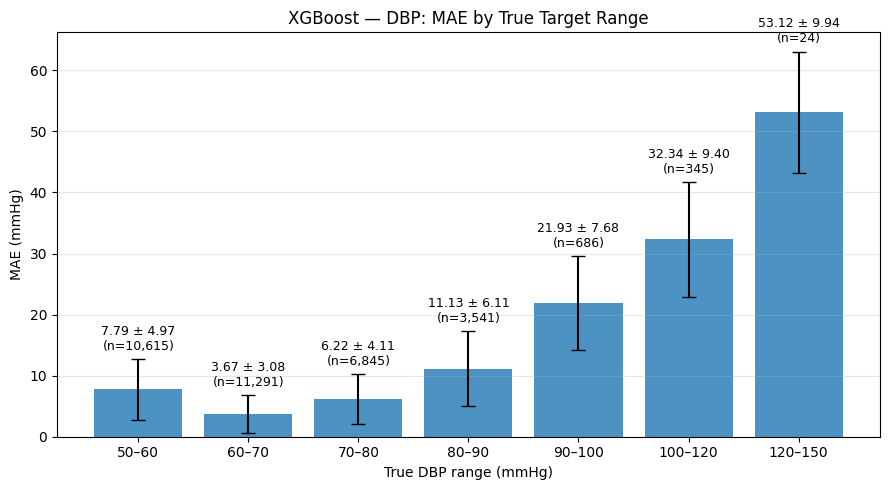

In [22]:
xgbmodel, y_test_pred = xgboost_model(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 13.3419
MSE : 178.0074
R²  : -0.0997
MAE : 10.5586


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


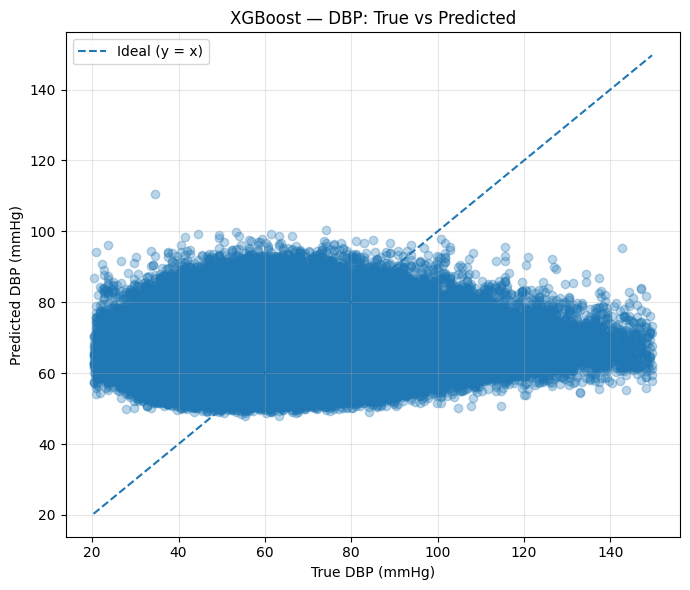

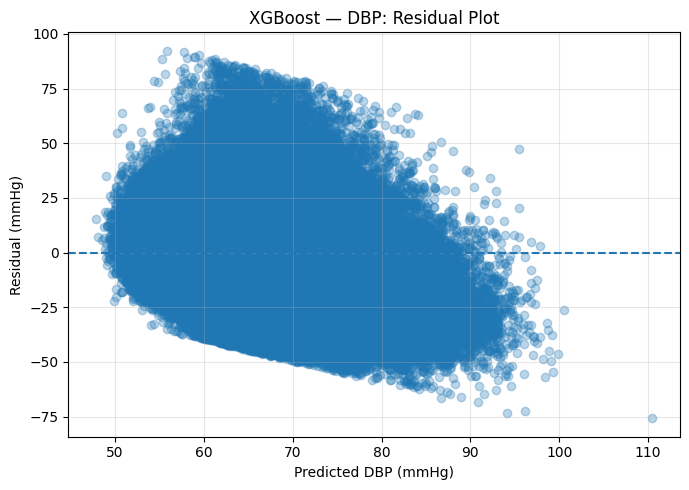

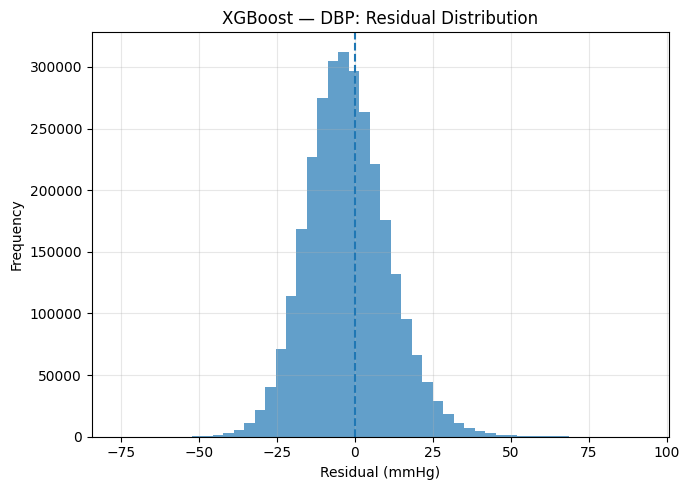

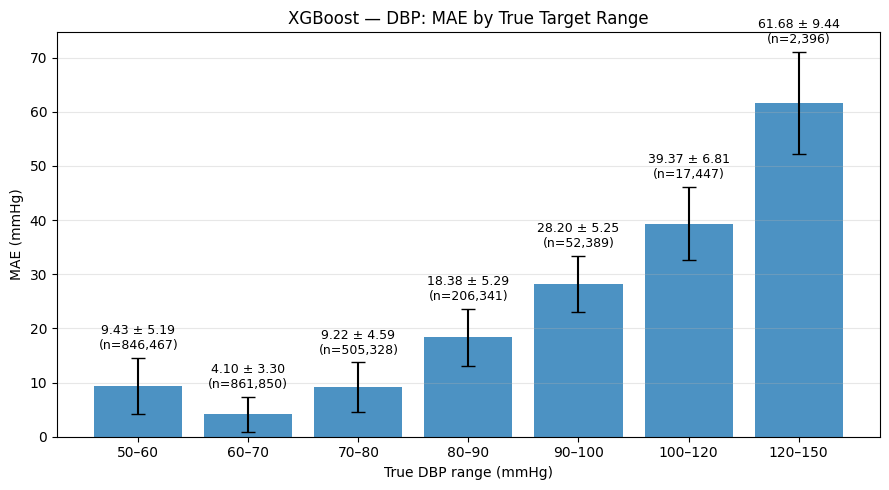

In [23]:
cross_gen(
    X_test_vital,
    y_test_vital,
    xgbmodel,
    "XGBoost",
    TARGET
)

## Light GBM ##

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total time=   2.7s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total time=   2.7s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=15; total time=   3.4s


/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=15; total time=   4.8s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time=   5.2s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time=   5.4s
[CV] END learning_rate=0.05, max_depth=10, n_estimators=100, num_leaves=15; total time=   1.9s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time=   7.6s
[CV] END learning_rate=0.05, max_depth=10, n_estimators=100, num_leaves=15; total time=   2.3s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=15; total time=   6.9s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=31; total time=   6.3s
[CV] END learning_rate=0.05, max_depth=10, n_estimators=100, num_leaves=15; total time=   4.7s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total time=  10.3s
[CV] END learning_rate=0.05, max_depth=-1, n_estim

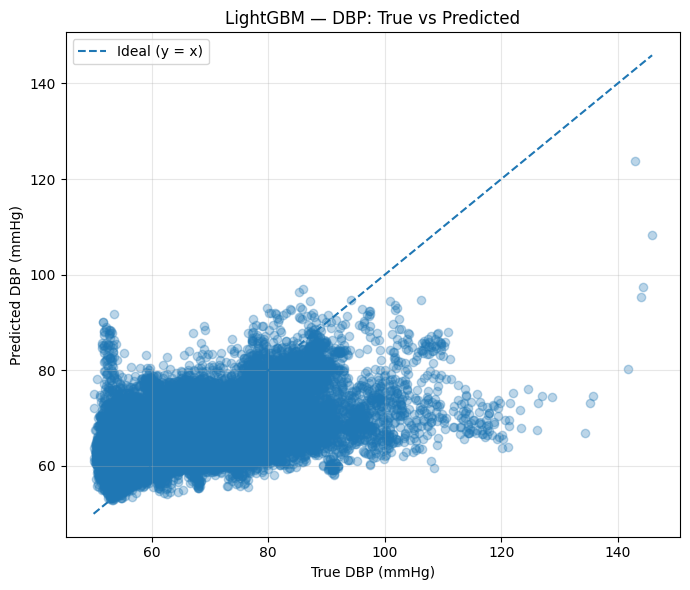

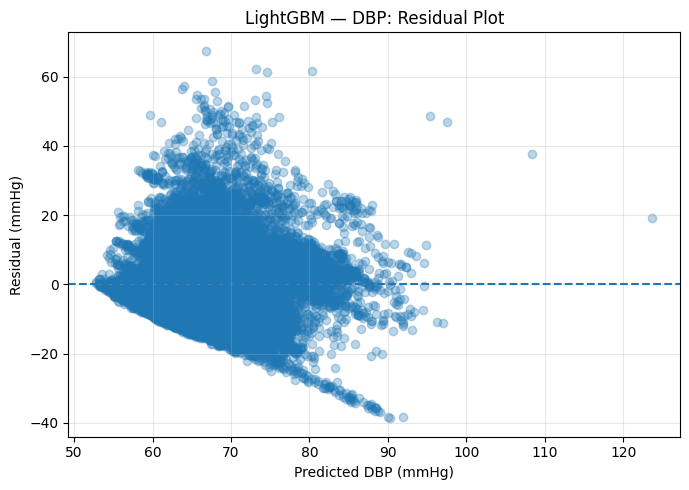

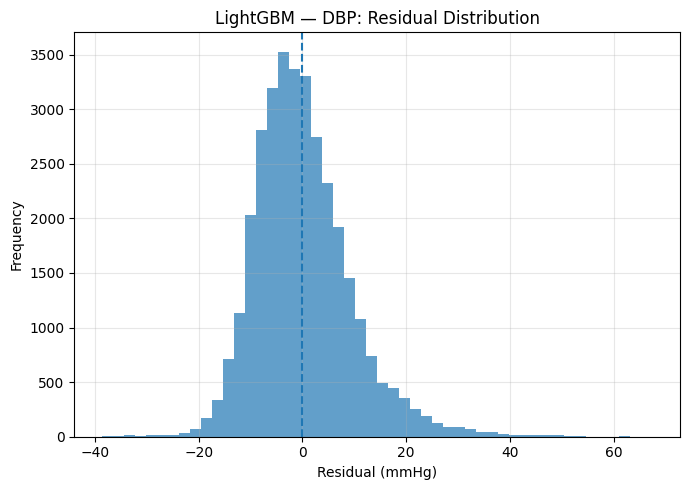

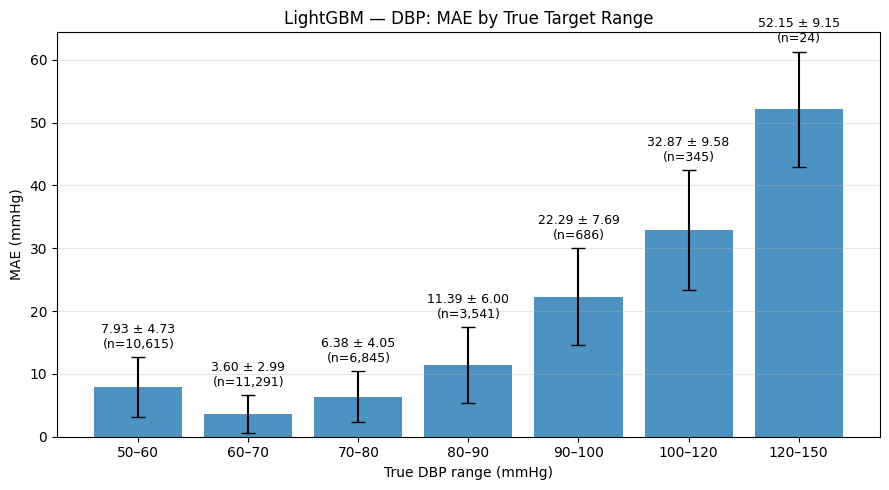

In [24]:
lgbmmodel, y_test_pred = lightgbm_model(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 12.9905
MSE : 168.7538
R²  : -0.0426
MAE : 10.2156


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


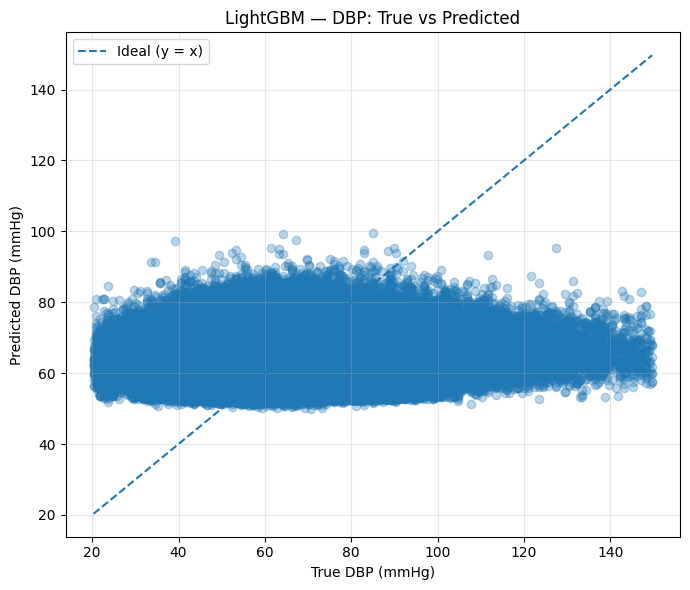

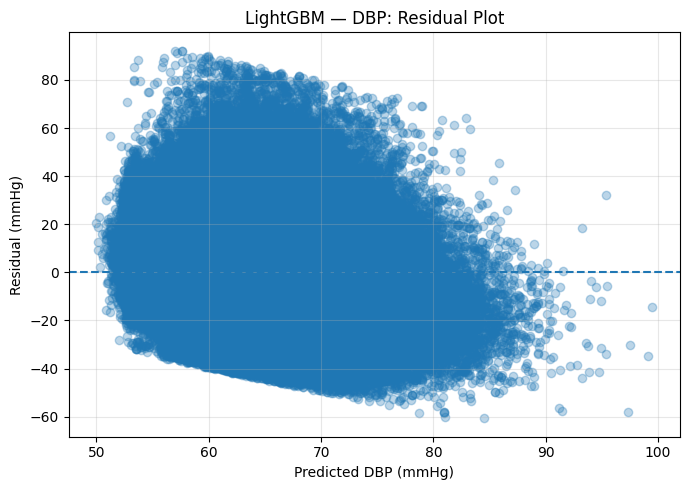

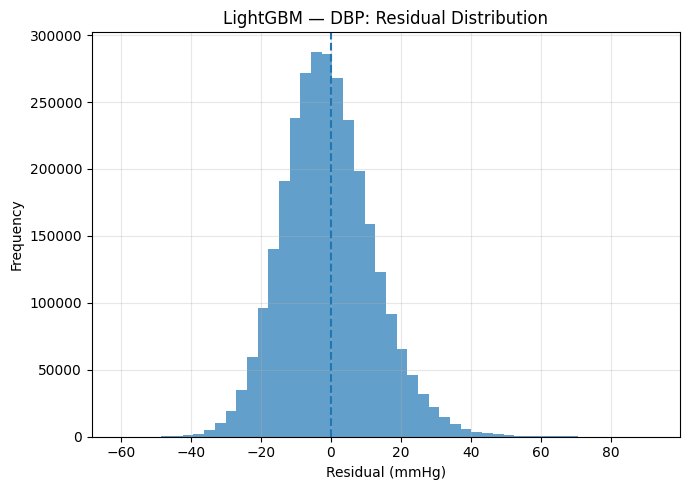

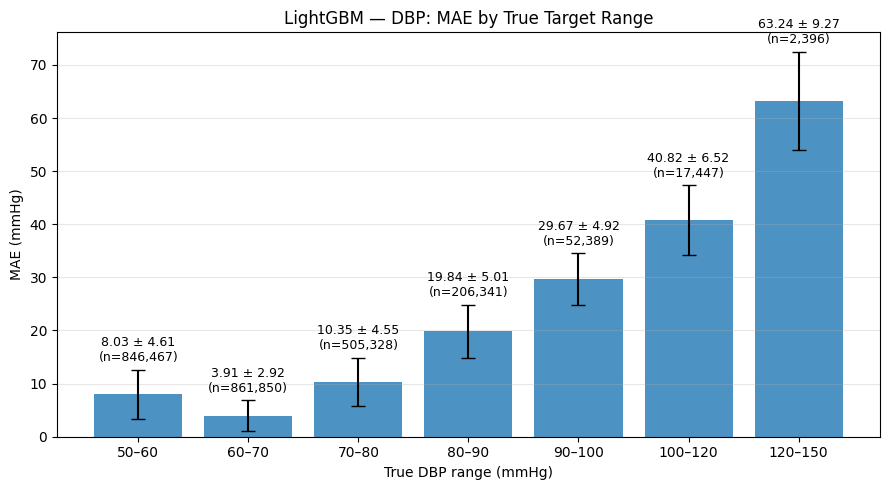

In [25]:
cross_gen(
    X_test_vital,
    y_test_vital,
    lgbmmodel,
    "LightGBM",
    TARGET
)

##  Matern 5/2 gpr ##

Best parameters:
{'kernel': 1**2 * Matern(length_scale=0.5, nu=2.5) + WhiteKernel(noise_level=1)}

Matern 5/2 GPR — DBP
--------------------------------
RMSE: 9.8301
MSE : 96.6305
R²  : 0.2265
MAE : 7.3764


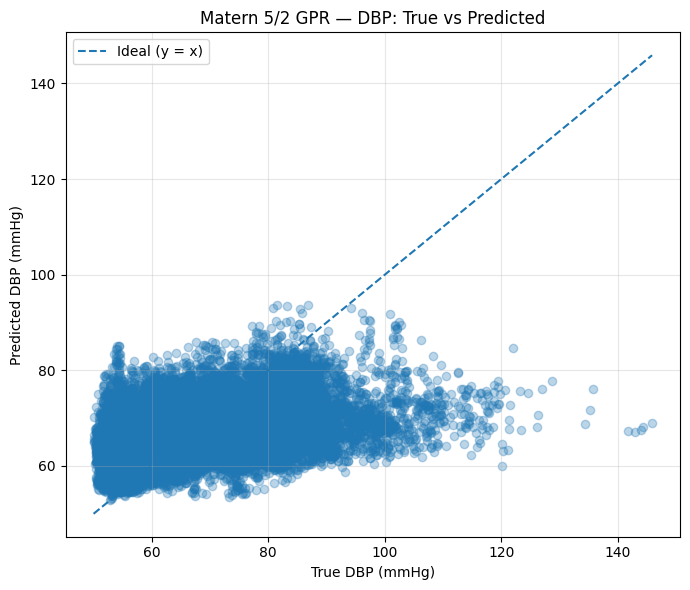

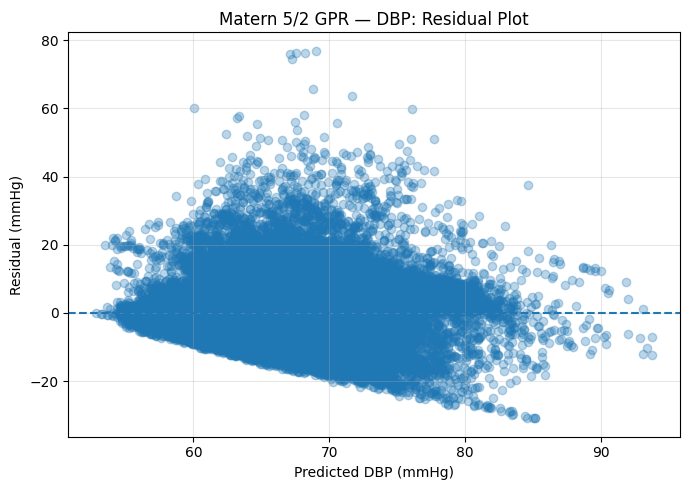

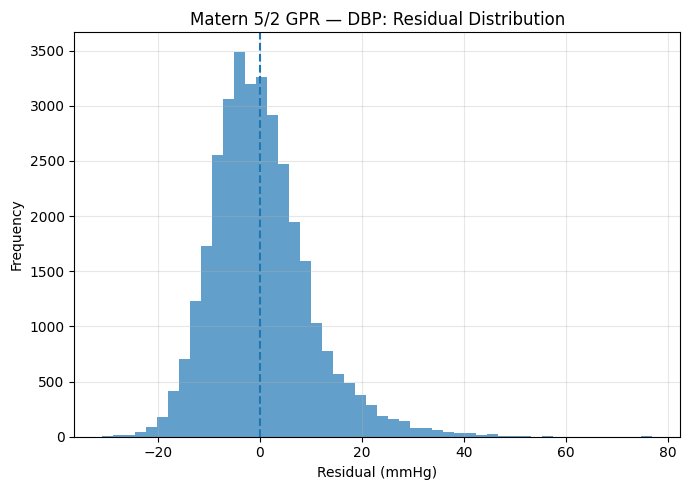

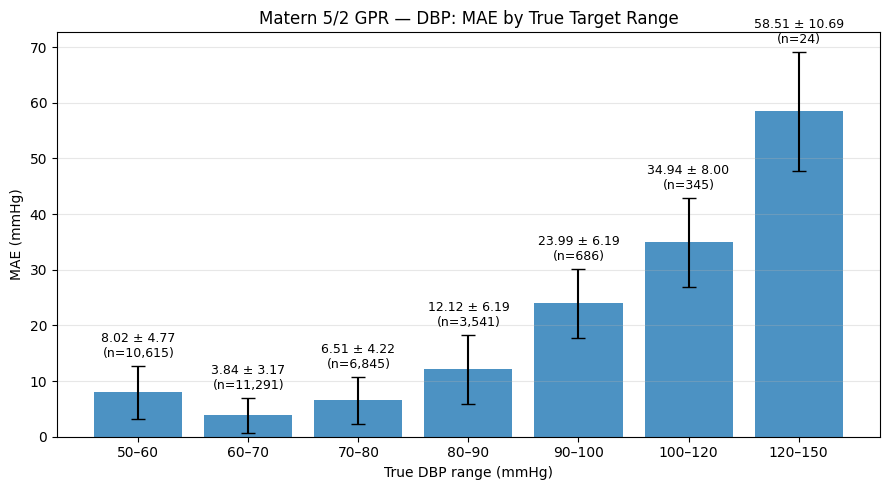

In [26]:
gpr_model, y_test_pred = gpr_matern(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 12.7816
MSE : 163.3682
R²  : -0.0093
MAE : 10.1498


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


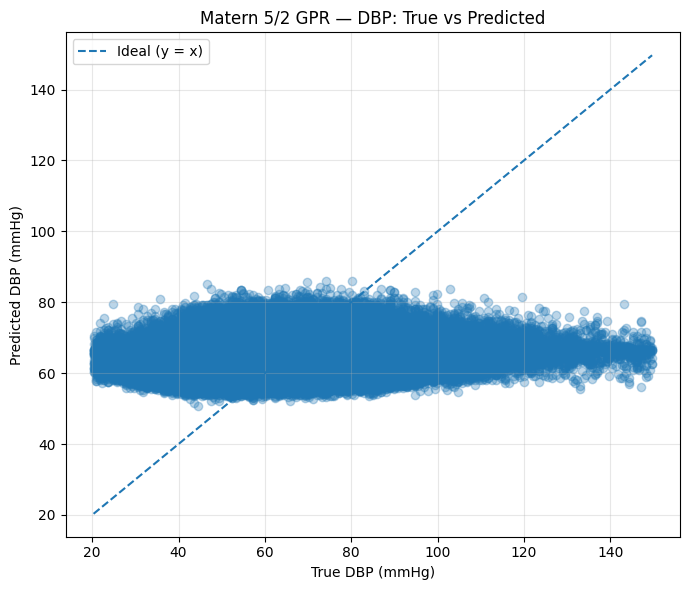

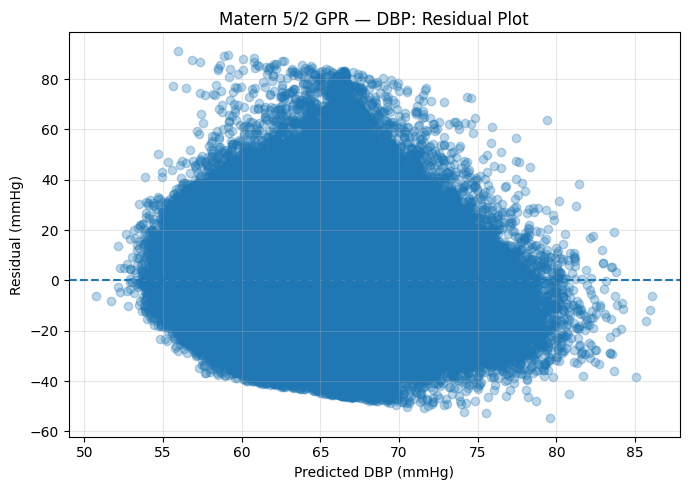

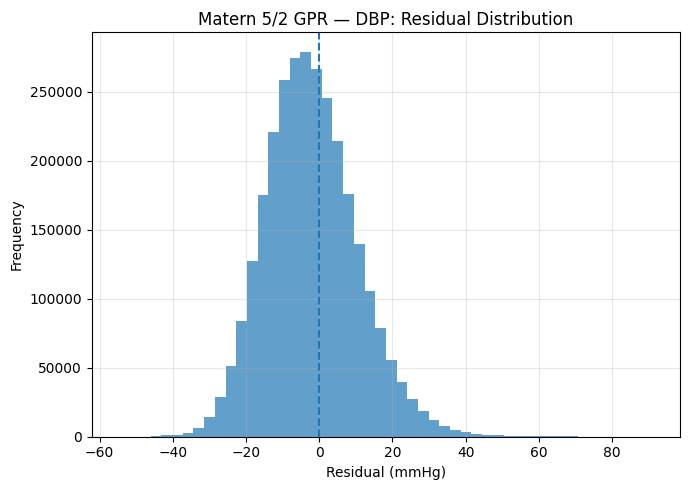

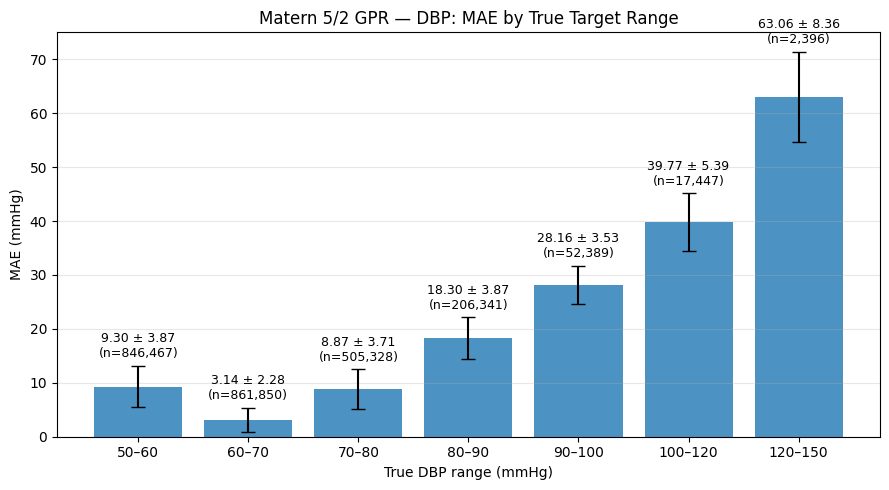

In [27]:
y_pred_vitaldb = predict_gpr_in_batches(
    model=gpr_model,
    X=X_test_vital,
    y_test=y_test_vital,
    target_name=TARGET,
    model_name="Matern 5/2 GPR",
    batch_size=10000
)

## Rational Quadratic GPR ##

GPR training samples: 5,000

Starting Rational Quadratic GPR GridSearch...
Fitting 3 folds for each of 3 candidates, totalling 9 fits


/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a bette


Best parameters:
{'kernel': 1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1)}

Best CV RMSE: 9.270206654745346

Best GPR model:
GaussianProcessRegressor(kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1),
                         normalize_y=True, random_state=42)

Starting batched prediction on 33,347 samples...
RMSE: 9.7487
MSE : 95.0381
R²  : 0.2392
MAE : 7.3472


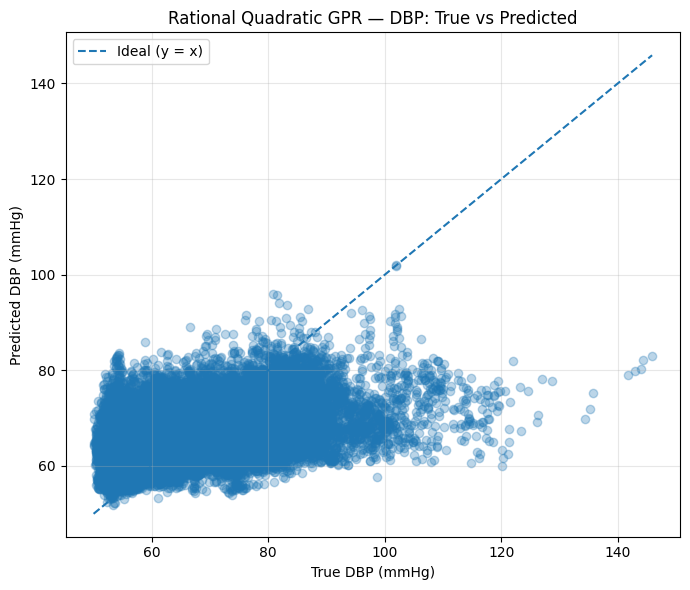

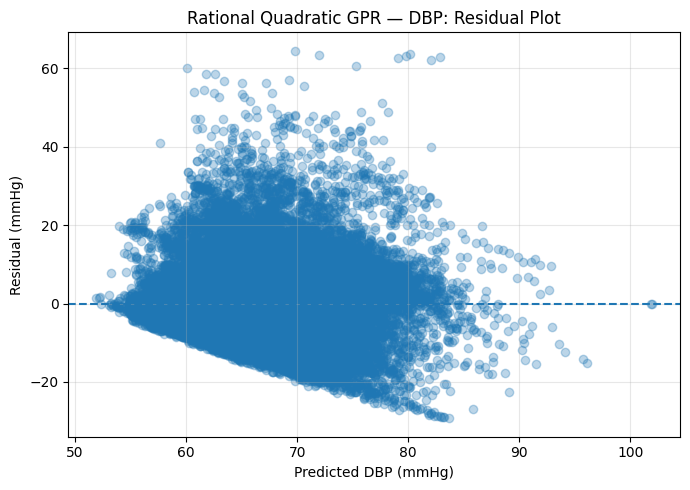

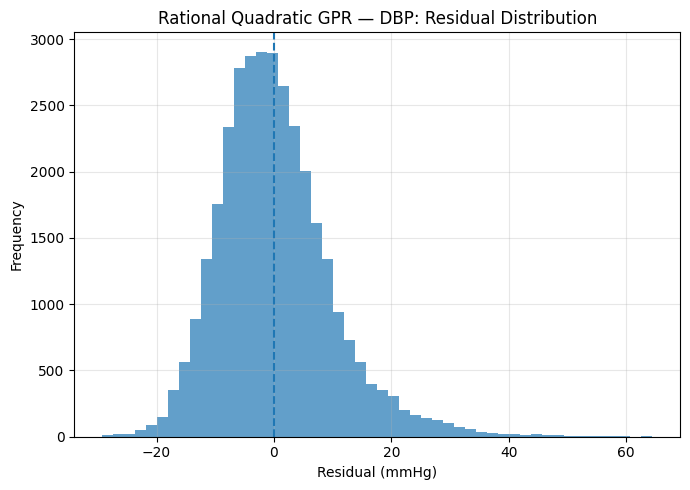

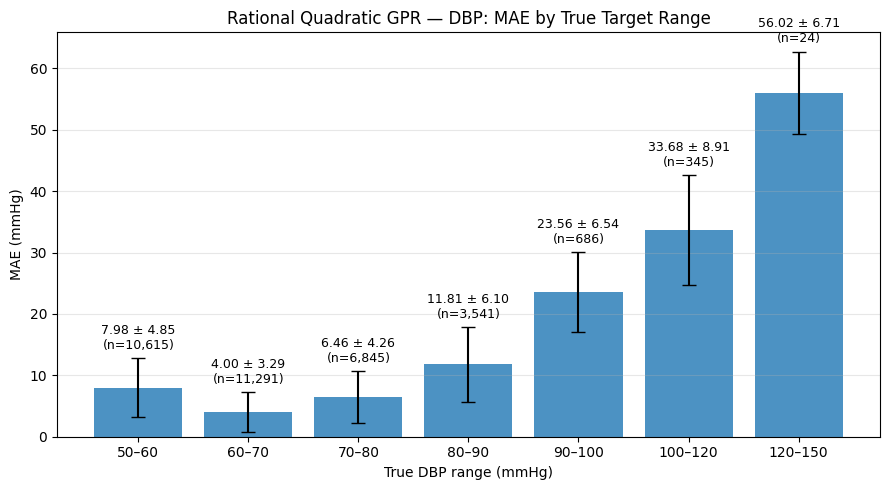

In [28]:
rq_model, y_test_pred = gpr_rational_quadratic(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 12.4694
MSE : 155.4858
R²  : 0.0394
MAE : 9.8283


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


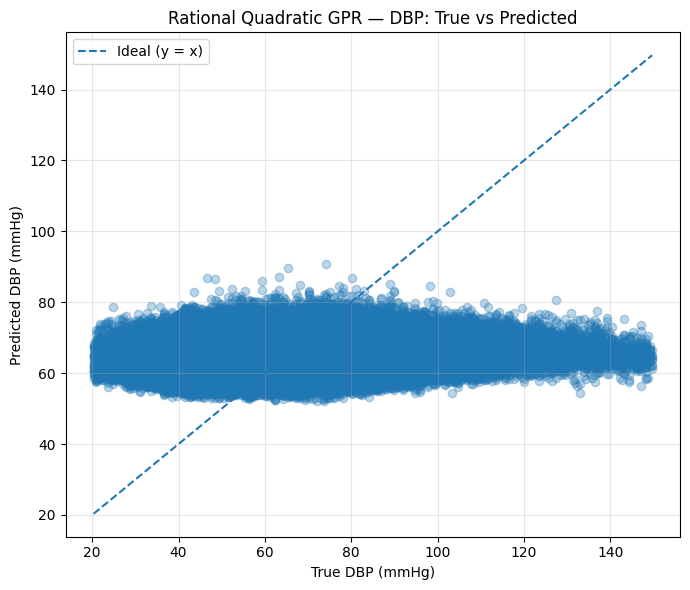

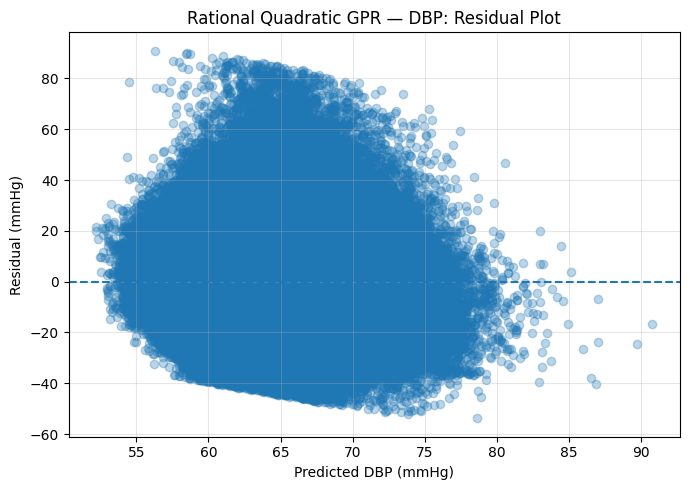

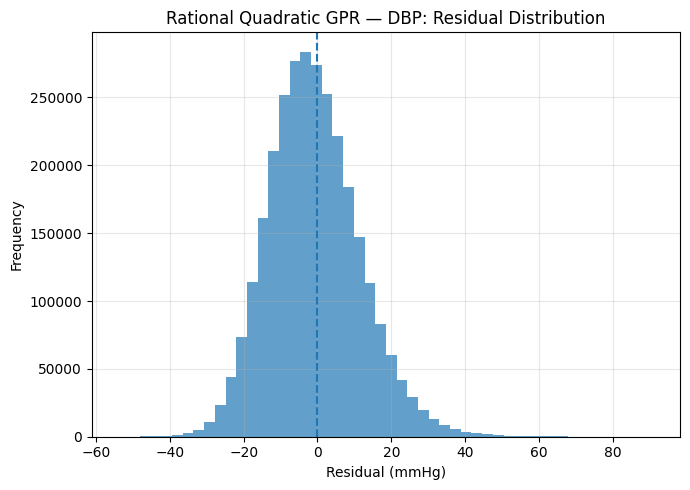

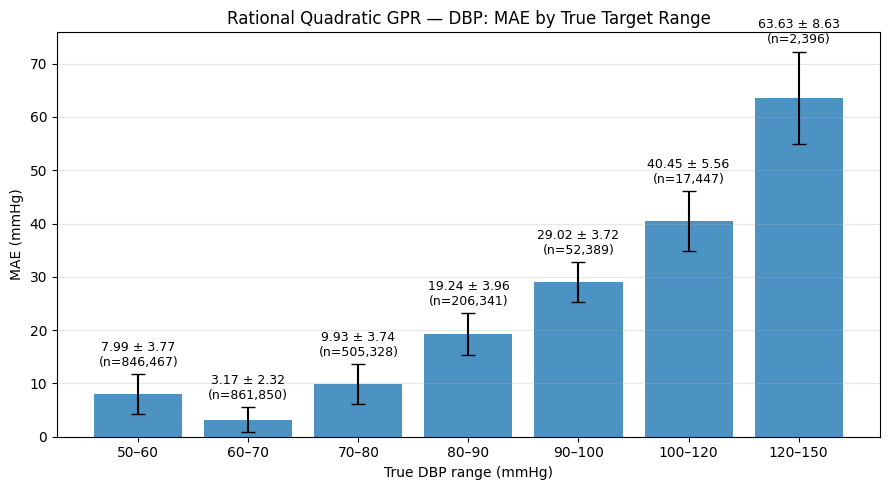

In [29]:
y_pred_vitaldb = predict_gpr_in_batches(
    rq_model,
    X_test_vital,
    y_test_vital,
    target_name=TARGET,
    model_name="Rational Quadratic GPR",
    batch_size=10000
)

## ANN ##

ANN training samples: 5,000

Starting ANN / MLP GridSearch...
Fitting 3 folds for each of 36 candidates, totalling 108 fits


/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum i


Best parameters:
{'activation': 'relu', 'alpha': 0.001, 'batch_size': 256, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.01}

Best CV RMSE: 10.25419814130721

Best ANN / MLP model:
MLPRegressor(alpha=0.001, batch_size=256, early_stopping=True,
             hidden_layer_sizes=(128, 64), learning_rate_init=0.01,
             max_iter=300, n_iter_no_change=20, random_state=42)

Starting batched prediction on 33,347 samples...
Processed 10,000 / 33,347
Processed 20,000 / 33,347
Processed 30,000 / 33,347
Processed 33,347 / 33,347

ANN / MLP Regressor — DBP
------------------------------------
RMSE: 9.9905
MSE : 99.8106
R²  : 0.2010
MAE : 7.7726


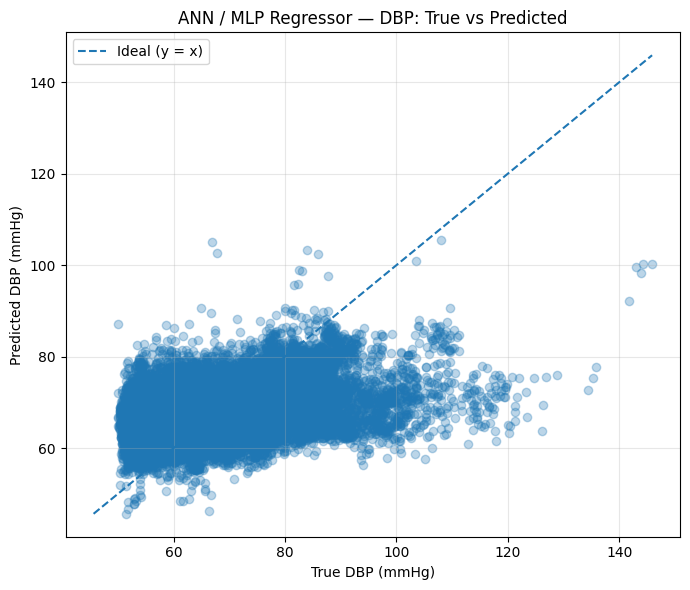

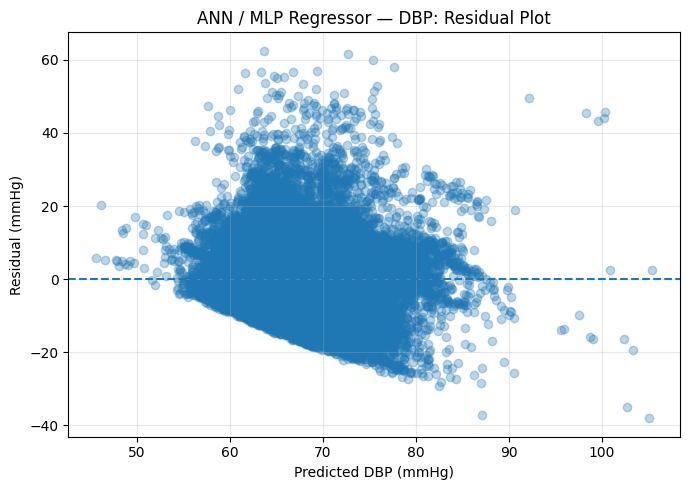

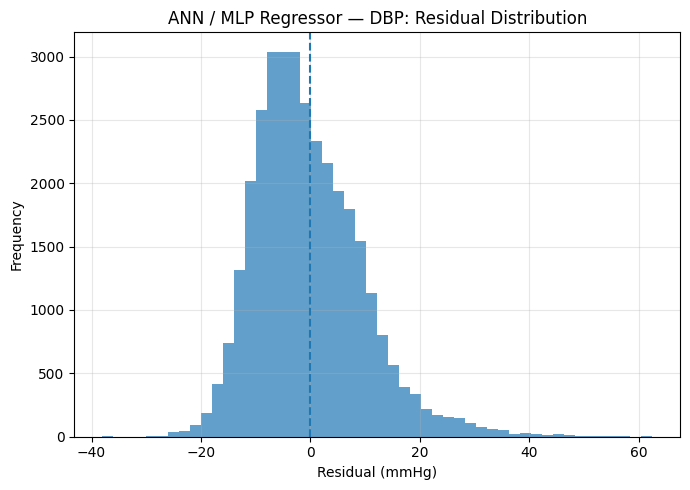

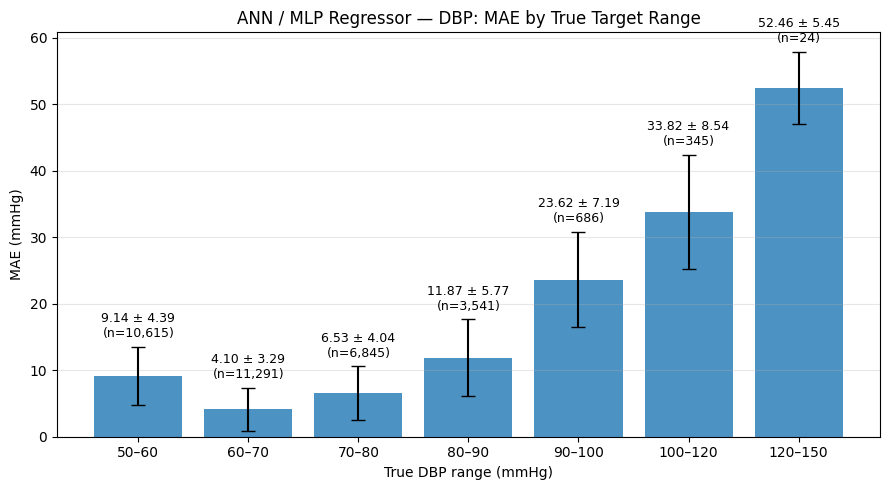

In [31]:
ann_model, y_test_pred = ann(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

Processed 10,000 / 2,928,374
Processed 20,000 / 2,928,374
Processed 30,000 / 2,928,374
Processed 40,000 / 2,928,374
Processed 50,000 / 2,928,374
Processed 60,000 / 2,928,374
Processed 70,000 / 2,928,374
Processed 80,000 / 2,928,374
Processed 90,000 / 2,928,374
Processed 100,000 / 2,928,374
Processed 110,000 / 2,928,374
Processed 120,000 / 2,928,374
Processed 130,000 / 2,928,374
Processed 140,000 / 2,928,374
Processed 150,000 / 2,928,374
Processed 160,000 / 2,928,374
Processed 170,000 / 2,928,374
Processed 180,000 / 2,928,374
Processed 190,000 / 2,928,374
Processed 200,000 / 2,928,374
Processed 210,000 / 2,928,374
Processed 220,000 / 2,928,374
Processed 230,000 / 2,928,374
Processed 240,000 / 2,928,374
Processed 250,000 / 2,928,374
Processed 260,000 / 2,928,374
Processed 270,000 / 2,928,374
Processed 280,000 / 2,928,374
Processed 290,000 / 2,928,374
Processed 300,000 / 2,928,374
Processed 310,000 / 2,928,374
Processed 320,000 / 2,928,374
Processed 330,000 / 2,928,374
Processed 340,000 /

/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


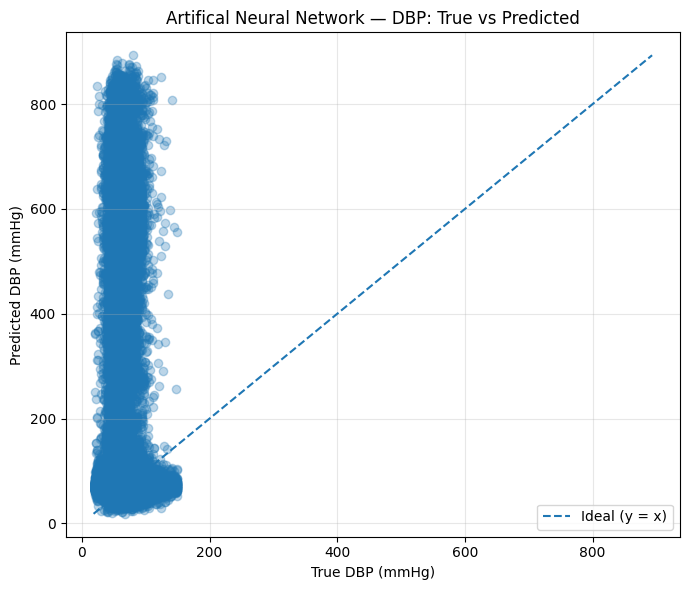

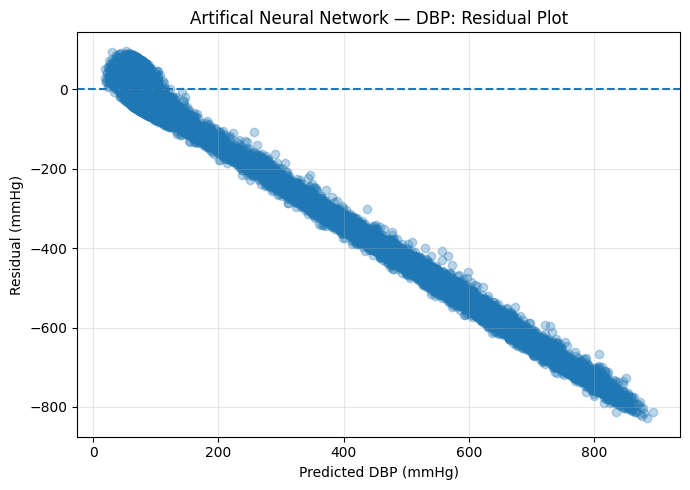

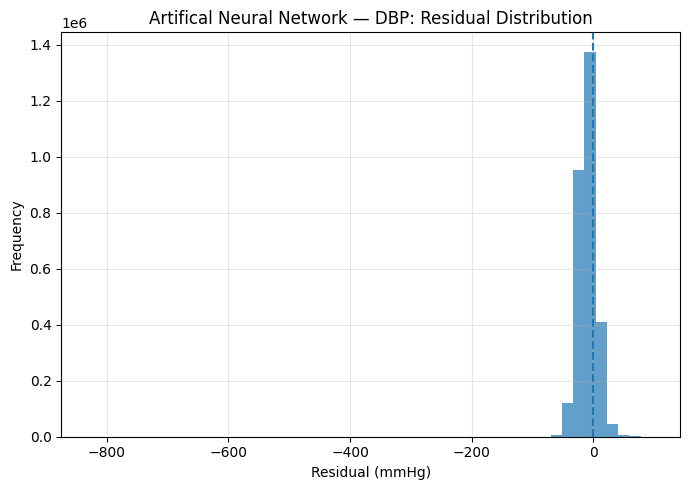

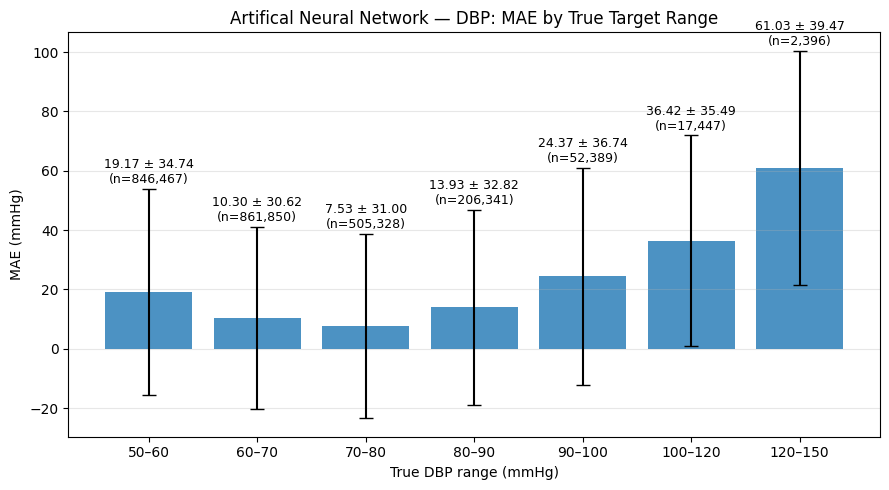

In [32]:
y_pred_vitaldb = predict_ann_in_batches(
    ann_model,
    X_test_vital,
y_test_vital,
    target_name=TARGET,
    model_name="Artifical Neural Network",
    batch_size=10000
)